# 🏴‍☠️ Pirate Pain Classification Challenge

> ⚓ *"Even pirates feel pain — let's teach the model to feel it too."*

---

## 📚 Table of Contents
0. [README](#readme)  
1. [Setup & Configuration](#setup)  
2. [Data Loading](#data-loading)  
3. [Import Libraries](#import-libraries)  
4. [Data Preprocessing](#data-preprocessing)  
5. [Sequence Building](#sequence-building)  
6. [DataLoaders](#dataloaders)  
7. [Network Hyperparameters](#hyperparameters)
8. [Model Architecture](#model-architecture)  
9. [Training Functions](#training-functions)  
10. [Model Training](#model-training)  
11. [Evaluation & Metrics](#evaluation)  
12. [Model Loading & Final Testing](#model-loading)  
13. [Competition Submission](#submission)

---

### ⚙️ Quick Configuration Map

> 🧭 *"If ye seek to tweak the code, here be where to look!"*

- 🧺 **Batch Size:** → [DataLoaders](#dataloaders)  
- ⚗️ **Hyperparameters:** → [Network Hyperparameters](#hyperparameters)  
- 🪞 **Window Size & Stride:** → [Sequence Building](#sequence-building)  
- ⚙️ **Model Type:** → [Setup & Configuration](#setup)  

---



---

### 💰 Treasure Storage — Models & Submissions
> 🏴‍☠️ *"A wise pirate always knows where his treasure be buried — guard yer models and submissions well!"*

- 💾 **Model & Submission Save/Load Path:** → [Setup & Configuration](#setup)  
  - 🗂️ Models be saved in a **`models/`** folder with the name:
    **`experiment_name_dd-mm-HH-MM.pt`** (day-month-hour-minute).
  - 📜 Submissions be saved in a **`submissions/`** folder with the filename format:  
    **`experiment_name_dd-mm-HH-MM.csv`** .
  - 🔡 All related model parameters are saved in **`models/`** folder with the  name **`experiment_name_dd-mm-HH-MM_config.json`** .

  
  *❗The experiment name is set as **`RnnType_Bi_dd-mm-HH-MM`** or **`RnnType_dd-mm-HH-MM`** depending on if it is bidirectional or not*
---






<a id="readme"></a>
## 0. Info



This section lists all the main parameters that can be modified to control data loading, model behavior, and training.

---

### 📁 File Paths
| Variable | Description | Default Value |
|-----------|--------------|----------------|
| `TRAIN_DATA_PATH` | Training features | `'pirate_pain_train.csv'` |
| `TRAIN_LABELS_PATH` | Training labels | `'pirate_pain_train_labels.csv'` |
| `TEST_DATA_PATH` | Test set for inference | `'pirate_pain_test.csv'` *(optional)* |
| `MODEL_SAVE_PATH` | Output model file | `'pirate_model.pt'` |
| `RESULTS_FILE` | CSV for predictions | `'results_<date-time>.csv'` |

---

### 🧠 Model & Architecture
| Parameter | Description | Typical Values |
|------------|--------------|----------------|
| `model_type` | Choose model class | `'RNN'`, `'LSTM'`, `'GRU'`, `'ANN'` |
| `input_size` | Number of features per time step | *auto-detected from data* |
| `hidden_size` | Hidden layer size | `64`, `128`, `256` |
| `num_layers` | Number of RNN layers | `1-4` |
| `dropout` | Dropout probability | `0.2–0.5` |
| `num_classes` | Output classes (pain levels) | *from label set* |

---

### 🏋️ Training Hyperparameters
| Parameter | Description | Default / Range |
|------------|--------------|-----------------|
| `batch_size` | Samples per batch | `512/2^n` |
| `learning_rate` | Optimizer learning rate | `1e-3` |
| `num_epochs` | Training iterations | `500` |
| `optimizer` | Optimization algorithm | `'AdamW'` |
| `criterion` | Loss function | `CrossEntropyLoss()` |
| `seed` | Random seed for reproducibility | `42` |

---

### 📤 Inference
| Parameter | Description |
|------------|--------------|
| `LOAD_MODEL_PATH` | Path to pretrained `.pt` model (optional) |
| `save_results` | Whether to write output CSV | `True` |

---

> 💡 *Tip:* Adjust hyperparameters in the “Configuration” or “Training Setup” cell before running the notebook.


<a id="setup"></a>
## 1. Setup & Configuration

*Optional: Connect to Google Drive (for Colab users)*

In [224]:
# from google.colab import drive
# drive.mount("/gdrive")
# current_dir = "/gdrive/My\\ Drive/AN2DL Challenge 1"
# %cd $current_dir

*Set Model Type*

In [225]:
RNN_TYPE = 'LSTM'            # 'RNN', 'LSTM', or 'GRU'
BIDIRECTIONAL = True        # True / False

*Set Model Save Name*

In [226]:
from datetime import datetime

# Get current date and time for submission filename
current_datetime = datetime.now().strftime("%d-%m-%H-%M")

if BIDIRECTIONAL:
    EXPERIMENT_NAME = f"{RNN_TYPE}_bi_{current_datetime}"
else:
    EXPERIMENT_NAME = f"{RNN_TYPE}_{current_datetime}"

SUBMISSION_FILENAME = f"{EXPERIMENT_NAME}.csv"
print(f"Experiment name: {EXPERIMENT_NAME}")
print(f"Submission filename: {SUBMISSION_FILENAME}")

Experiment name: LSTM_bi_16-11-18-06
Submission filename: LSTM_bi_16-11-18-06.csv


<a id="data-loading"></a>
## 2. Data Loading

Load training and test datasets from CSV files.

In [227]:
import pandas as pd

X_train = pd.read_csv('an2dl2526c1/pirate_pain_train.csv')
y_train = pd.read_csv('an2dl2526c1/pirate_pain_train_labels.csv')

<a id="import-libraries"></a>
## 3. Import Libraries

Set random seeds for reproducibility and import all necessary packages.

In [228]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader

# Directory configuration
logs_dir = "tensorboard"
models_dir = "models"



# Model save/load paths
MODEL_SAVE_PATH = f"{models_dir}/{EXPERIMENT_NAME}_model.pt"
MODEL_LOAD_PATH = f"{models_dir}/{EXPERIMENT_NAME}_model.pt"

!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p {models_dir}

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from datetime import datetime
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


'pkill' is not recognized as an internal or external command,
operable program or batch file.


PyTorch version: 2.10.0.dev20251109+cu128
Device: cuda


A subdirectory or file -p already exists.
Error occurred while processing: -p.
A subdirectory or file models already exists.
Error occurred while processing: models.


<a id="data-preprocessing"></a>
## 4. Data Preprocessing

Explore data, split into train/val/test sets, normalize features, and encode labels.

In [229]:
# Print the shape of the dataset
print(f"Dataset shape: {X_train.shape}")

# Display the first few rows of the dataset
X_train.head(10)

Dataset shape: (105760, 40)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.073167e-06,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.074800e-06,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5
7,0,7,2,2,2,2,two,two,two,1.038597,...,8.829074e-07,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.621055e-06,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5
9,0,9,0,2,2,2,two,two,two,1.054999,...,1.609114e-06,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5


### 4.1 Data Exploration

In [230]:
from sklearn.preprocessing import LabelEncoder

# Merge features and labels
data = X_train.merge(y_train, on='sample_index')

# Create a mapping dictionary to convert categorical labels to numerical values
# map_dict = {'none': 0, 'one': 1, 'two': 2}
# data['n_legs'] = data['n_legs'].map(map_dict)
# data['n_hands'] = data['n_hands'].map(map_dict)
# data['n_eyes'] = data['n_eyes'].map(map_dict)

# print("Loading test dataset for final evaluation...")

cols = ['n_legs', 'n_hands', 'n_eyes']
unique_values = {col: X_train[col].unique().tolist() for col in cols}

unique_values

{'n_legs': ['two', 'one+peg_leg'],
 'n_hands': ['two', 'one+hook_hand'],
 'n_eyes': ['two', 'one+eye_patch']}

In [231]:
map_dict = {'two': 2, 'one+peg_leg': 1}
data['n_legs'] = data['n_legs'].map(map_dict)

map_dict = {'two': 2, 'one+hook_hand': 1}
data['n_hands'] = data['n_hands'].map(map_dict)

map_dict = {'two': 2, 'one+eye_patch': 1}
data['n_eyes'] = data['n_eyes'].map(map_dict)

print("Mapped string columns to numeric values!")
print(data.head())

Mapped string columns to numeric values!
   sample_index  time  pain_survey_1  pain_survey_2  pain_survey_3  \
0             0     0              2              0              2   
1             0     1              2              2              2   
2             0     2              2              0              2   
3             0     3              2              2              2   
4             0     4              2              2              2   

   pain_survey_4  n_legs  n_hands  n_eyes  joint_00  ...      joint_22  \
0              1       2        2       2  1.094705  ...  1.945042e-06   
1              2       2        2       2  1.135183  ...  6.765107e-07   
2              2       2        2       2  1.080745  ...  1.698525e-07   
3              2       2        2       2  0.938017  ...  5.511079e-07   
4              2       2        2       2  1.090185  ...  1.735459e-07   

   joint_23      joint_24  joint_25  joint_26  joint_27  joint_28  joint_29  \
0  0.000004  1

In [232]:
data.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,1.990923,1.990923,1.990923,0.943095,...,3.972126e-05,4.176794e-05,3.561780e-05,3.138109e-05,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.094841,0.094841,0.094841,0.202051,...,4.974496e-03,5.472244e-03,1.235450e-03,4.062914e-04,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000e+00,1.510494e-07,0.000000e+00,1.063144e-08,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.828277,...,6.545878e-08,3.321650e-07,3.275038e-07,2.841805e-07,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.005126,...,8.302747e-07,1.095971e-06,1.024209e-06,8.746147e-07,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.081039,...,2.800090e-06,3.079465e-06,3.021830e-06,2.507548e-06,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.407968,...,1.442198e+00,1.305001e+00,2.742411e-01,3.643074e-02,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5


In [233]:
list_to_remove = ['n_legs', 'n_hands', 'n_eyes', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_30']

if data.columns.isin(list_to_remove).any():
  data = data.drop(columns=['n_legs', 'n_hands', 'n_eyes', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_30'])
  data.head()
else:
  print("Usless features already removed")

In [234]:
data.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_08,joint_09,joint_10,joint_11,joint_12,joint_26,joint_27,joint_28,joint_29,label
0,0,0,2,0,2,1,1.094705,0.985281,1.018302,1.010385,...,0.712989,1.050142,0.529555,0.447370,1.091046,0.017592,0.013508,0.026798,0.027815,no_pain
1,0,1,2,2,2,2,1.135183,1.021175,0.994343,1.052364,...,0.722685,1.060313,0.446810,0.414432,1.045862,0.013352,0.000000,0.013377,0.013716,no_pain
2,0,2,2,0,2,2,1.080745,0.962842,1.009588,0.977169,...,0.668043,1.011410,0.432499,0.431535,1.088221,0.016225,0.008110,0.024097,0.023105,no_pain
3,0,3,2,2,2,2,0.938017,1.081592,0.998021,0.987283,...,0.702085,1.047223,0.478806,0.420665,1.096832,0.011832,0.007450,0.028613,0.024648,no_pain
4,0,4,2,2,2,2,1.090185,1.032145,1.008710,0.963658,...,0.712197,1.044731,0.452906,0.476537,1.103968,0.005360,0.002532,0.033026,0.025328,no_pain


## Preprocessing testing dataset

In [235]:
# Load the actual test dataset (this doesn't have labels)
X_test_final_df = pd.read_csv('an2dl2526c1/pirate_pain_test.csv')

# Map string columns to numeric values first
map_dict = {'two': 2, 'one+peg_leg': 1}
X_test_final_df['n_legs'] = X_test_final_df['n_legs'].map(map_dict)

map_dict = {'two': 2, 'one+hook_hand': 1}
X_test_final_df['n_hands'] = X_test_final_df['n_hands'].map(map_dict)

map_dict = {'two': 2, 'one+eye_patch': 1}
X_test_final_df['n_eyes'] = X_test_final_df['n_eyes'].map(map_dict)

print("Mapped string columns to numeric values!")
print(X_test_final_df.head())

# Now convert inputs from float64 to float32
X_test_final_df = X_test_final_df.astype(np.float32)

Mapped string columns to numeric values!
   sample_index  time  pain_survey_1  pain_survey_2  pain_survey_3  \
0             0     0              2              2              2   
1             0     1              2              2              2   
2             0     2              2              2              2   
3             0     3              1              2              2   
4             0     4              2              2              2   

   pain_survey_4  n_legs  n_hands  n_eyes  joint_00  ...  joint_21  joint_22  \
0              2       2        2       2  0.842535  ...  0.000003  0.000004   
1              2       2        2       2  0.898836  ...  0.000003  0.000004   
2              2       2        2       2  0.957765  ...  0.000006  0.000004   
3              2       2        2       2  0.832596  ...  0.000005  0.000004   
4              0       2        2       2  0.805971  ...  0.000006  0.000004   

   joint_23  joint_24  joint_25  joint_26  joint_27  join

In [236]:
def build_sequences_test(df, window=200, stride=200):
    assert window >= stride
    assert window > 0
    assert stride > 0

    dataset = []

    # Get feature columns (exclude sample_index and time)
    columns = [col for col in df.columns if col not in ['sample_index', 'time']]

    for id in df['sample_index'].unique():
        temp = df[df['sample_index'] == id][columns].values

        # Padding
        padding_len = (window - len(temp) % window) % window
        padding = np.zeros((padding_len, len(columns)), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build windows
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            idx += stride

    return np.array(dataset)

In [237]:
# ------ Normalize test data ------

list_to_remove = ['n_legs', 'n_hands', 'n_eyes', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_30']

if X_test_final_df.columns.isin(list_to_remove).any():
    X_test_final_df = X_test_final_df.drop(columns=['n_legs', 'n_hands', 'n_eyes', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_30'])
else:
  print("Usless features already removed")

# --- Load and preprocess the actual test dataset ---
# Define the columns to be normalised (use training statistics for proper normalization)
# Exclude 'sample_index', 'time', and 'label' as they were excluded during training sequence building
# Also exclude 'joint_30' as it was removed from training data
scale_columns = [col for col in X_test_final_df.columns
                 if col != 'sample_index' and col != 'time' and col != 'joint_30']

# Calculate the minimum and maximum values from the training data only
mins_train = X_test_final_df[scale_columns].min()
maxs_train = X_test_final_df[scale_columns].max()

# Apply normalisation to the specified columns in all datasets
for column in scale_columns:
    # Normalise the testing set
    if maxs_train[column] != mins_train[column]:
      X_test_final_df[column] = (X_test_final_df[column] - mins_train[column]) / (maxs_train[column] - mins_train[column])

X_test_final_df.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_07,joint_08,joint_09,joint_10,joint_11,joint_12,joint_26,joint_27,joint_28,joint_29
0,0.0,0.0,1.0,1.0,1.0,1.0,0.561563,0.553352,0.419037,0.270175,...,0.654303,0.737832,0.742275,0.100076,0.146564,0.745300,0.014909,0.045098,0.012882,0.010178
1,0.0,1.0,1.0,1.0,1.0,1.0,0.599088,0.532067,0.461325,0.327922,...,0.684443,0.772454,0.710705,0.103457,0.174403,0.594262,0.053679,0.055375,0.013892,0.029085
2,0.0,2.0,1.0,1.0,1.0,1.0,0.638365,0.583960,0.445804,0.308796,...,0.676488,0.799646,0.722061,0.143175,0.159973,0.652024,0.042305,0.039620,0.016286,0.040638
3,0.0,3.0,0.5,1.0,1.0,1.0,0.554938,0.488719,0.443494,0.355023,...,0.650563,0.738087,0.709363,0.141007,0.167449,0.709558,0.037477,0.031101,0.008568,0.018730
4,0.0,4.0,1.0,1.0,1.0,0.0,0.537192,0.528780,0.413159,0.363199,...,0.653239,0.703021,0.681513,0.140234,0.186249,0.590142,0.015210,0.019426,0.008189,0.013444


### 4.2 Categorical Encoding

In [238]:
import pandas as pd
from sklearn.model_selection import train_test_split

# df has columns: ['sample_index', 'label']
N_VAL_USERS = 90
N_TEST_USERS = 0   # now also 0 test users is allowed

# --- Step 1: Compute each user's dominant label (or label distribution)
user_labels = (
    data.groupby('sample_index')['label']
    .agg(lambda x: x.value_counts().index[0])  # dominant label per user
    .reset_index()
)

print("Original label distribution:", user_labels['label'].value_counts().to_dict())

# --- Step 2: Split into train/val/test keeping real label proportions
if N_TEST_USERS > 0:
    test_val_ratio = (N_VAL_USERS + N_TEST_USERS) / len(user_labels)
    train_users, temp_users = train_test_split(
        user_labels['sample_index'],
        test_size=test_val_ratio,
        stratify=user_labels['label'],
        random_state=None
    )

    # Split temp into val/test (also stratified)
    temp_labels = user_labels[user_labels['sample_index'].isin(temp_users)]
    val_ratio_in_temp = N_VAL_USERS / (N_VAL_USERS + N_TEST_USERS)
    val_users, test_users = train_test_split(
        temp_labels['sample_index'],
        test_size=1 - val_ratio_in_temp,
        stratify=temp_labels['label'],
        random_state=None
    )
else:
    # Only train/val split
    val_ratio = N_VAL_USERS / len(user_labels)
    train_users, val_users = train_test_split(
        user_labels['sample_index'],
        test_size=val_ratio,
        stratify=user_labels['label'],
        random_state=None
    )
    test_users = []  # empty list

# === Step 3: Create the training set (keep all selected users) ===
train_labels = user_labels[user_labels['sample_index'].isin(train_users)]
train_users = train_labels['sample_index'].tolist()  # keep all users

# Compute validation and test label distributions
val_label_counts = user_labels[user_labels['sample_index'].isin(val_users)]['label'].value_counts().to_dict()
test_label_counts = user_labels[user_labels['sample_index'].isin(test_users)]['label'].value_counts().to_dict()
print("Validation and Test distributions:")
print("Validation label counts:", val_label_counts)
print("Test label counts:", test_label_counts)

# --- Step 4: Filter your main df
df_train = data[data['sample_index'].isin(train_users)]
df_val = data[data['sample_index'].isin(val_users)]
df_test = data[data['sample_index'].isin(test_users)]  # empty if N_TEST_USERS=0

# --- Step 5: Check label proportions
print("Label proportions:")
print("Train:\n", df_train['label'].value_counts(normalize=True))
print("Val:\n", df_val['label'].value_counts(normalize=True))
print("Test:\n", df_test['label'].value_counts(normalize=True))


Original label distribution: {'no_pain': 511, 'low_pain': 94, 'high_pain': 56}
Validation and Test distributions:
Validation label counts: {'no_pain': 69, 'low_pain': 13, 'high_pain': 8}
Test label counts: {}
Label proportions:
Train:
 label
no_pain      0.774081
low_pain     0.141856
high_pain    0.084063
Name: proportion, dtype: float64
Val:
 label
no_pain      0.766667
low_pain     0.144444
high_pain    0.088889
Name: proportion, dtype: float64
Test:
 Series([], Name: proportion, dtype: float64)


### 4.3 Stratified Train/Val/Test Split

In [239]:
df_train.shape, df_val.shape, df_test.shape

((91360, 24), (14400, 24), (0, 24))

In [240]:
# Print the total number of pirates for each dataset
print(f"Total pirates in training set: {df_train['sample_index'].nunique()}")
print(f"Total pirates in validation set: {df_val['sample_index'].nunique()}")
print(f"Total pirates in test set: {df_test['sample_index'].nunique()}")

Total pirates in training set: 571
Total pirates in validation set: 90
Total pirates in test set: 0


In [241]:
df_train

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_08,joint_09,joint_10,joint_11,joint_12,joint_26,joint_27,joint_28,joint_29,label
0,0,0,2,0,2,1,1.094705,0.985281,1.018302,1.010385,...,0.712989,1.050142,0.529555,0.447370,1.091046,0.017592,0.013508,0.026798,0.027815,no_pain
1,0,1,2,2,2,2,1.135183,1.021175,0.994343,1.052364,...,0.722685,1.060313,0.446810,0.414432,1.045862,0.013352,0.000000,0.013377,0.013716,no_pain
2,0,2,2,0,2,2,1.080745,0.962842,1.009588,0.977169,...,0.668043,1.011410,0.432499,0.431535,1.088221,0.016225,0.008110,0.024097,0.023105,no_pain
3,0,3,2,2,2,2,0.938017,1.081592,0.998021,0.987283,...,0.702085,1.047223,0.478806,0.420665,1.096832,0.011832,0.007450,0.028613,0.024648,no_pain
4,0,4,2,2,2,2,1.090185,1.032145,1.008710,0.963658,...,0.712197,1.044731,0.452906,0.476537,1.103968,0.005360,0.002532,0.033026,0.025328,no_pain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105755,660,155,2,2,0,0,1.051738,0.906653,0.852813,0.714132,...,0.793007,0.818443,0.696164,0.676377,1.065835,0.007856,0.026876,0.173566,0.221921,no_pain
105756,660,156,2,2,0,2,1.027651,0.894214,0.834575,0.790003,...,0.742828,0.861304,0.642332,0.677491,1.021720,0.026795,0.012778,0.075945,0.116763,no_pain
105757,660,157,0,2,2,2,1.113381,0.803824,0.856149,0.659963,...,0.781024,0.872811,0.723307,0.751857,1.031213,0.036982,0.028014,0.075978,0.078339,no_pain
105758,660,158,2,2,2,2,1.058100,0.902272,0.787495,0.685756,...,0.759178,0.790487,0.702029,0.678239,1.045568,0.046405,0.017922,0.097109,0.106807,no_pain


In [242]:
data_no_pain = data[data['label'] == 'no_pain']
data_no_pain['joint_00'].mean()

np.float64(0.9600490053935573)

In [243]:
data_no_pain['joint_00'].var()

np.float64(0.03259213768774184)

In [244]:
data_low_pain = data[data['label'] == 'low_pain']
data_low_pain['joint_00'].mean()

np.float64(0.8776655637118013)

In [245]:
data_low_pain['joint_00'].var()

np.float64(0.05696169002817177)

In [246]:
data_high_pain = data[data['label'] == 'high_pain']
data_high_pain['joint_00'].mean()

np.float64(0.8982135710283117)

In [247]:
data_high_pain['joint_00'].var()

np.float64(0.07704996641161217)

In [248]:
scale_columns = [col for col in data.columns
                 if col != 'sample_index' and col != 'time' and col != 'joint_30' and col != 'label']

# Calculate the minimum and maximum values from the training data only
mins_train = df_train[scale_columns].min()
maxs_train = df_train[scale_columns].max()

mins_val = df_val[scale_columns].min()
maxs_val = df_val[scale_columns].max()

mins_test = df_test[scale_columns].min()
maxs_test = df_test[scale_columns].max()

# Apply normalisation to the specified columns in all datasets
for column in scale_columns:
    if maxs_train[column] != mins_train[column] and mins_val[column] != maxs_val[column] and mins_test[column] != maxs_test[column]:
      df_train[column] = (df_train[column] - mins_train[column]) / (maxs_train[column] - mins_train[column])

      # Normalise the validation set
      df_val[column] = (df_val[column] - mins_val[column]) / (maxs_val[column] - mins_val[column])

      # Normalise the test set
      df_test[column] = (df_test[column] - mins_test[column]) / (maxs_test[column] - mins_test[column])

    # elif column == 'n_hands' or column == 'n_eyes' or column == 'n_legs':
    #   df_train[column] = 0.5
    #   df_val[column] = 0.5
    #   df_test[column] = 0.5


In [249]:
df_train

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_08,joint_09,joint_10,joint_11,joint_12,joint_26,joint_27,joint_28,joint_29,label
0,0,0,1.0,0.0,1.0,0.5,0.777507,0.738252,0.779512,0.804419,...,0.478382,0.753815,0.272106,0.269510,0.762947,0.014214,0.011376,0.018978,0.020291,no_pain
1,0,1,1.0,1.0,1.0,1.0,0.806256,0.765147,0.761153,0.838021,...,0.486231,0.761224,0.217448,0.245846,0.727910,0.010748,0.000000,0.009473,0.010006,no_pain
2,0,2,1.0,0.0,1.0,1.0,0.767592,0.721439,0.772834,0.777832,...,0.441994,0.725601,0.207995,0.258133,0.760757,0.013097,0.006830,0.017065,0.016856,no_pain
3,0,3,1.0,1.0,1.0,1.0,0.666220,0.810416,0.763971,0.785928,...,0.469554,0.751688,0.238584,0.250324,0.767434,0.009505,0.006274,0.020264,0.017981,no_pain
4,0,4,1.0,1.0,1.0,1.0,0.774297,0.773366,0.772162,0.767017,...,0.477740,0.749873,0.221475,0.290464,0.772967,0.004216,0.002132,0.023389,0.018477,no_pain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105755,660,155,1.0,1.0,0.0,0.0,0.746990,0.679338,0.652703,0.567290,...,0.543164,0.585036,0.382161,0.434035,0.743398,0.006255,0.022634,0.122919,0.161896,no_pain
105756,660,156,1.0,1.0,0.0,1.0,0.729882,0.670018,0.638728,0.628019,...,0.502539,0.616258,0.346602,0.434835,0.709191,0.021736,0.010761,0.053784,0.085181,no_pain
105757,660,157,0.0,1.0,1.0,1.0,0.790771,0.602290,0.655260,0.523931,...,0.533463,0.624639,0.400091,0.488262,0.716552,0.030063,0.023592,0.053808,0.057150,no_pain
105758,660,158,1.0,1.0,1.0,1.0,0.751509,0.676055,0.602652,0.544576,...,0.515776,0.564671,0.386035,0.435373,0.727682,0.037765,0.015093,0.068772,0.077918,no_pain


In [250]:
# Define a function to inspect sensor data for a specific label
def inspect_label(label, df):
    # Filter the DataFrame for the specified label and limit to 159 rows
    data = df[df['label'] == label][['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']][:159]

    # Plot the sensor data for each axis
    axis = data.plot(subplots=True, figsize=(17, 9), title=label)

    # Adjust legend position for each subplot
    for ax in axis:
        ax.legend(loc='lower right')

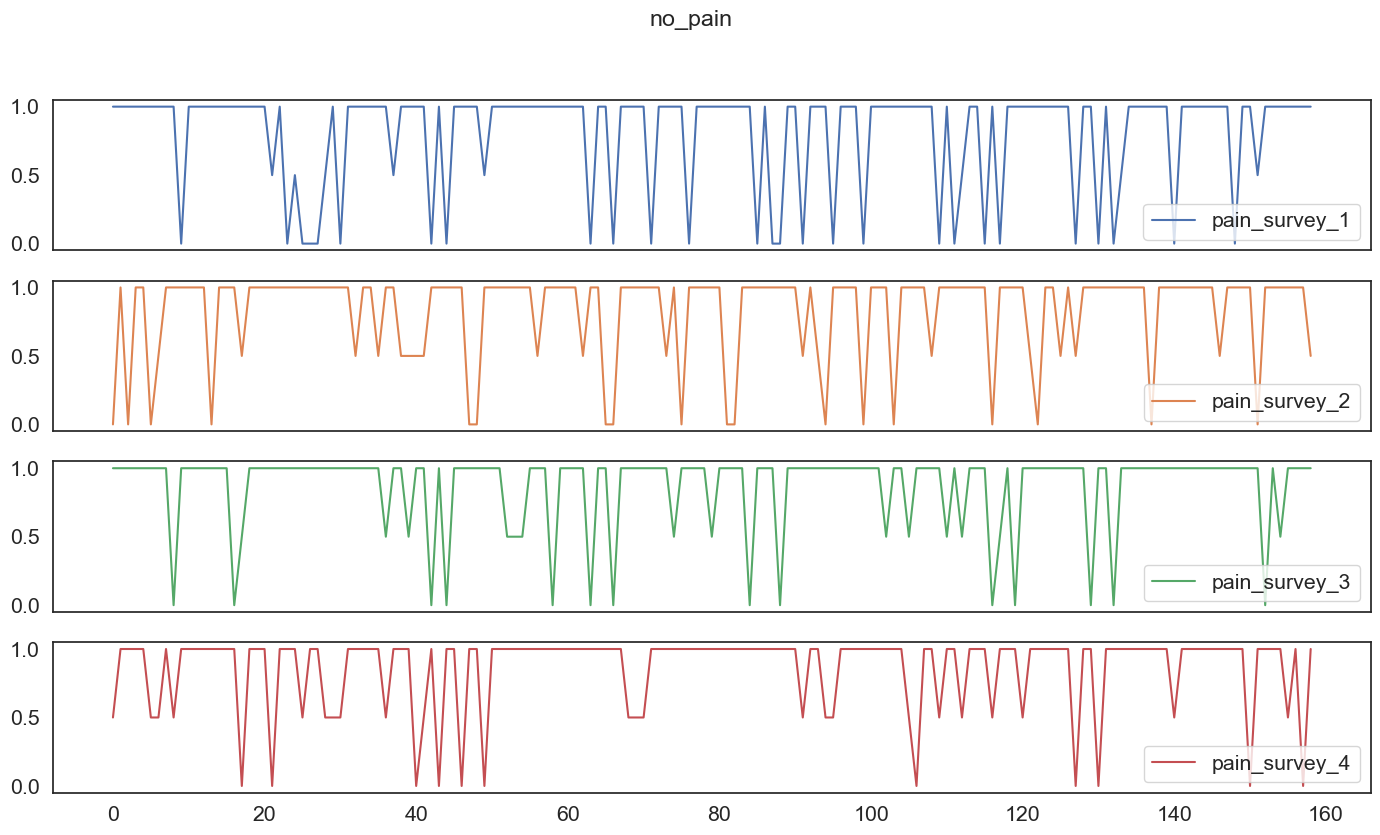

In [251]:
# Normalized "no_pain" training data
inspect_label('no_pain', df_train)

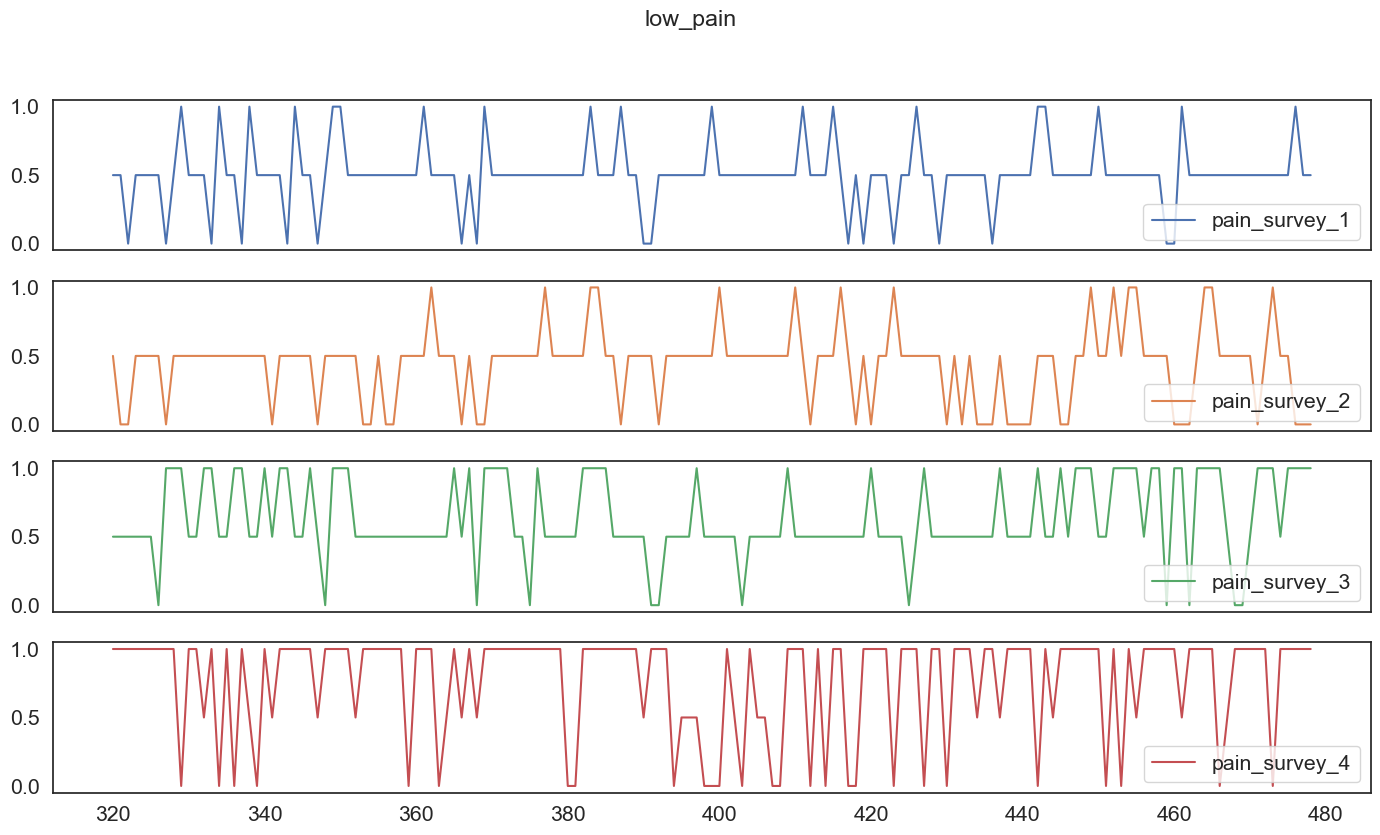

In [252]:
# Normalized "low_pain" training data
inspect_label('low_pain', df_train)

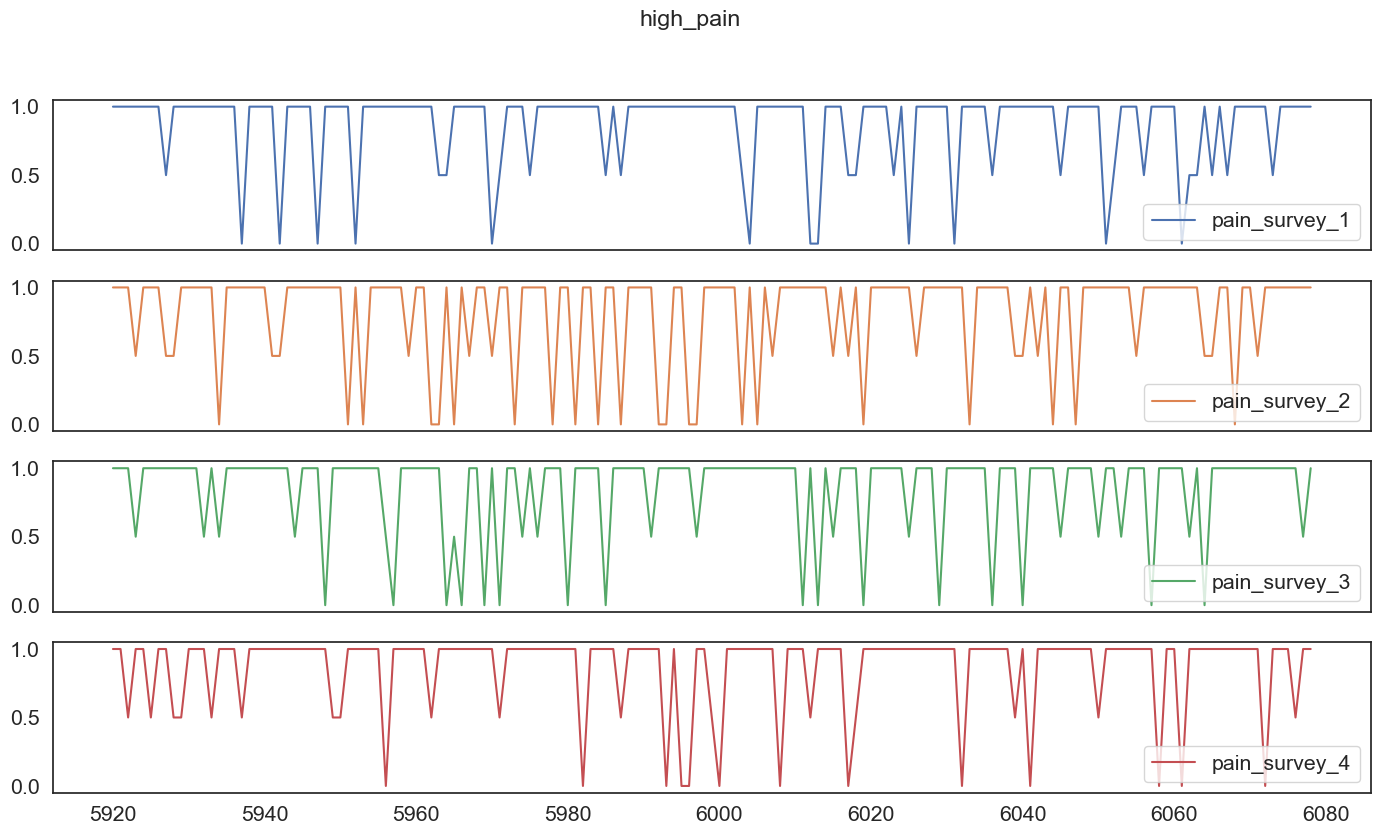

In [253]:
# Normalized "high_pain" training data
inspect_label('high_pain', df_train)

In [254]:
# Define a function to inspect sensor data for a specific label
def inspect_label(label, df):
    # Filter the DataFrame for the specified label and limit to 159 rows
    data = df[df['label'] == label][['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05' , 'joint_06', 'joint_07' , 'joint_08', 'joint_09' , 'joint_10', 'joint_11' , 'joint_12']][:159]

    # Plot the sensor data for each axis
    axis = data.plot(subplots=True, figsize=(17, 9), title=label)

    # Adjust legend position for each subplot
    for ax in axis:
        ax.legend(loc='lower right')

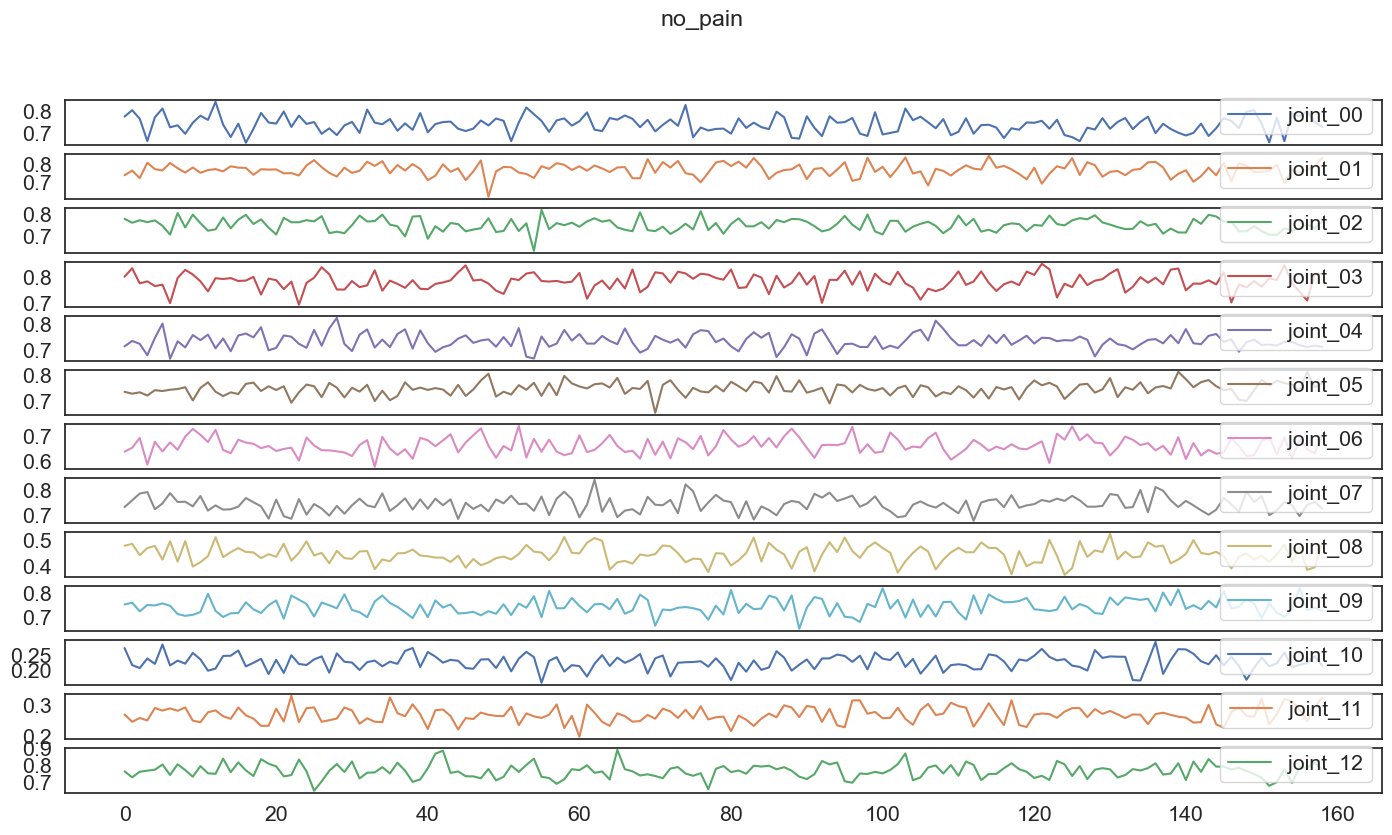

In [255]:
# Normalized "no_pain" training data
inspect_label('no_pain', df_train)

In [256]:
# Normalized "low_pain" training data
# inspect_label('low_pain', df_train)

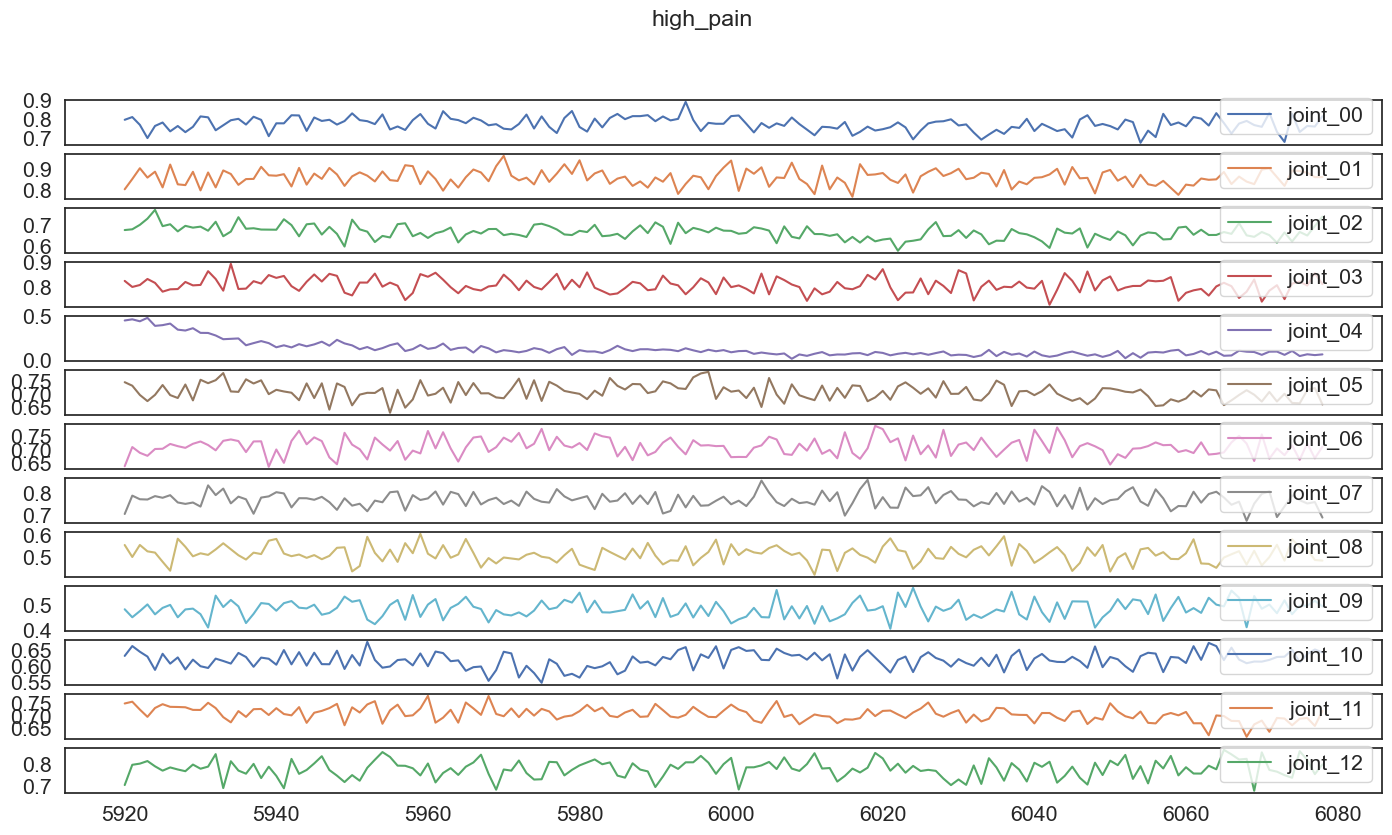

In [257]:
# Normalized "high_pain" training data
inspect_label('high_pain', df_train)

### 4.4 Feature Normalization

In [258]:
# Initialise a dictionary to count occurrences of each activity in the training set
training_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0
}

# Count occurrences of each activity for unique IDs in the training set
for id in df_train['sample_index'].unique():
    label = df_train[df_train['sample_index'] == id]['label'].values[0]
    training_labels[label] += 1


#if 'joint_30' in df_train.columns:
#    df_train = df_train.drop(columns=['joint_30']) # we deleted this joint since has no final effect during training

# Print the distribution of training labels
print('Training labels:', training_labels)

# Initialise a dictionary to count occurrences of each activity in the training set
val_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0
}

# Count occurrences of each activity for unique IDs in the training set
for id in df_val['sample_index'].unique():
    label = df_val[df_val['sample_index'] == id]['label'].values[0]
    val_labels[label] += 1


#if 'joint_30' in df_val.columns:
#    df_val = df_val.drop(columns=['joint_30']) # we deleted this joint since has no final effect during training

# Print the distribution of validation labels
print('Validation labels:', val_labels)

# Initialise a dictionary to count occurrences of each activity in the test set
test_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0
}

# Count occurrences of each activity for unique IDs in the test set
for id in df_test['sample_index'].unique():
    label = df_test[df_test['sample_index'] == id]['label'].values[0]
    test_labels[label] += 1
#if 'joint_30' in df_test.columns:
#    df_test = df_test.drop(columns=['joint_30']) # we deleted this joint since has no final effect during training

# Print the distribution of test labels
print('Test labels:', test_labels)

Training labels: {'no_pain': 442, 'low_pain': 81, 'high_pain': 48}
Validation labels: {'no_pain': 69, 'low_pain': 13, 'high_pain': 8}
Test labels: {'no_pain': 0, 'low_pain': 0, 'high_pain': 0}


### 4.5 Label Distribution Analysis

In [259]:
# Define a training mapping of label names to integer labels
train_label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}

# Map label names to integers in the training set
df_train['label'] = df_train['label'].map(train_label_mapping)

# Define a validation mapping of label names to integer labels
val_label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}

# Map label names to integers in the validation set
df_val['label'] = df_val['label'].map(val_label_mapping)

test_label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2
}

# Map label names to integers in the test set
df_test['label'] = df_test['label'].map(test_label_mapping)


<a id="sequence-building"></a>
## 5. Sequence Building

Convert variable-length time-series into fixed-size windows for RNN input.

In [260]:

# Define window and stride boolean variable -> if True, during training we will visit more time the same pirate with overlapping windows
# if False, each pirate will be visited only once during training
one_pirate_window = True

In [261]:
if one_pirate_window:
    # Define the window size
    WINDOW_SIZE = 68 # before: 80

    # Stride size
    STRIDE = 17
else:
    # Define the window size -> select an higher window size in order to get more pirates
    WINDOW_SIZE = 160

    # Stride size
    STRIDE = 160

### 5.1 Window & Stride Configuration

In [262]:
def build_sequences(df, window=200, stride=200):
    # Sanity check to ensure the window is divisible by the stride
    assert window >= stride
    assert window > 0
    assert stride > 0

    # Initialise lists to store sequences and their corresponding labels
    dataset = []
    labels = []
    sample_ids = [] # Added: list to store original sample_index for each sequence

    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():

        # Extract pirate sample index data for the current sample index
        columns = [col for col in df.columns if col not in ['sample_index', 'label', 'time']]

        temp = df[df['sample_index'] == id][columns].values

        # Retrieve the label for the current pirate
        label = df[df['sample_index'] == id]['label'].values[0]

        # Calculate padding length to ensure full windows
        padding_len = window - len(temp) % window

        # Create zero padding and concatenate with the data
        padding = np.zeros((padding_len, len(columns)), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            labels.append(label)
            sample_ids.append(id) # Added: Append the sample_id for each generated sequence
            idx += stride

    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)
    labels = np.array(labels)
    sample_ids = np.array(sample_ids) # Added: Convert sample_ids to numpy array

    return dataset, labels, sample_ids # Modified: Return sample_ids as well

### 5.2 Build Sequences Function

In [263]:
# Generate sequences and labels for the training set
X_train, y_train, train_sample_ids = build_sequences(df_train, WINDOW_SIZE, STRIDE)

# Generate sequences and labels for the validation set
X_val, y_val, val_sample_ids = build_sequences(df_val, WINDOW_SIZE, STRIDE)

# Generate sequences and labels for the test set
X_test, y_test, test_sample_ids = build_sequences(df_test, WINDOW_SIZE, STRIDE)

# Print the shapes of the generated datasets and their labels
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}, train_sample_ids shape: {train_sample_ids.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}, val_sample_ids shape: {val_sample_ids.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}, test_sample_ids shape: {test_sample_ids.shape}")

X_train shape: (5139, 68, 21), y_train shape: (5139,), train_sample_ids shape: (5139,)
X_val shape: (810, 68, 21), y_val shape: (810,), val_sample_ids shape: (810,)
X_test shape: (0,), y_test shape: (0,), test_sample_ids shape: (0,)


### 5.3 Generate Sequences for Train/Val/Test

In [264]:
# Convert dataset into float32 for PyTorch compatibility
X_train = X_train.astype('float32')
X_val = X_val.astype('float32')
X_test = X_test.astype('float32')

### 5.4 Data Type Conversion & Cleaning

In [265]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [266]:
# Discard nan values from the dataset
if np.isnan(X_train).any() or np.isnan(X_val).any() or np.isnan(X_test).any():
    X_train = np.nan_to_num(X_train)
    X_val = np.nan_to_num(X_val)
    X_test = np.nan_to_num(X_test)


In [267]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels and sample_ids)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train), torch.from_numpy(train_sample_ids))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val), torch.from_numpy(val_sample_ids))
test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test), torch.from_numpy(test_sample_ids))

<a id="dataloaders"></a>
## 6. DataLoaders

Create PyTorch DataLoaders for efficient batching and parallel loading.

In [268]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 512 # we can change it depending on the GPU RAM available (by default 512)

In [269]:
def make_loader(ds, batch_size, shuffle, drop_last, sampler=None):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
        sampler=sampler
    )

In [270]:
from torch.utils.data import WeightedRandomSampler

# Compute class counts
class_counts = np.bincount(y_train)
class_weights = 1. / class_counts
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.float32), num_samples=len(sample_weights), replacement=True)

# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False, sampler=sampler)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [271]:
from collections import Counter

batch_labels = []
for _, yb, _ in train_loader: # Unpack all three items, ignoring features and sample_ids
    batch_labels.extend(yb.tolist())
    if len(batch_labels) > 5000:  # just check some batches
        break

print("Simulated batch distribution:", Counter(batch_labels))

Simulated batch distribution: Counter({2: 1742, 0: 1691, 1: 1687})


In [272]:
# Get one batch from the training data loader
for xb, yb, _ in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Features batch shape: torch.Size([512, 68, 21])
Labels batch shape: torch.Size([512])


In [273]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

<a id="hyperparameters"></a>
## 7. Network Hyperparameters

Configure training settings, architecture parameters, and regularization.

In [274]:
# Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 132        # Neurons per layer -> prev hidden size = 128

# Regularisation
DROPOUT_RATE = 0.30     # Dropout probability

# For now disable weight decay
L1_LAMBDA = 1e-6        # L1 penalty
L2_LAMBDA = 1e-3        # L2 penalty


# Set up loss function and optimizer

# TO GIVE DIFFERENT WEIGHTS TO THE LOSS DEPENDING ON THE INVERSE OF EACH LABEL TOTAL NUMBER:
# Set up loss function and optimizer
# from sklearn.utils.class_weight import compute_class_weight
# classes = np.unique(y_train)
# class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
# class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weights)
# print(f"Class weights (order = {classes}): {class_weights.cpu().numpy()}")


# TO GIVE FIXED WEIGHTS TO THE LOSS FUNCTION DEPENDING ON THE LABELS DISTRIBUTION:
# weights = torch.tensor([1.0, 1.2, 1.4]).to(device)
# criterion = nn.CrossEntropyLoss(weight=weights)

# criterion = nn.CrossEntropyLoss()


# TO NOT CHANGE THE WEIGHTS, BUT WITH LABEL SMOOTHING
# alpha = torch.tensor([0.5, 1.5, 2.0])
# criterion = nn.CrossEntropyLoss(label_smoothing=0.1)


# TO WEIGHT MORE THE "MORE DIFFICULT" CASES AND THE LESS FREQUENT LABELS:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()
alpha = None
# alpha = torch.tensor([0.7, 1.3, 1.7], dtype=torch.float32, device=device)  # None if we don't want to alterate the weights of each label losses (FocalLoss already do it)
criterion = FocalLoss(alpha=alpha, gamma=2.2)  # gamma = 0 it's like Crossentropy(), gamma < 1 it's like in between Crossentropy and FocalLoss,
                                               # gamma = 1 it's a good compromise, gamma = 1.5 or gamma = 2 to weight so much the less present labels

In [275]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

<a id="model-architecture"></a>
## 8. Model Architecture

Custom RNN/LSTM/GRU classifier with configurable bidirectionality and dropout.

### 8.1 Recurrent Classifier Class

In [276]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type= RNN_TYPE,        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=BIDIRECTIONAL,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0 # dropout between RNN layers, applied for regularization

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional, # We are defining a bidirectional RNN since we want to extract also the future contextual information for making better predictions
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes) # output layer for classifying

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x) # feeds the input sequence into the RNN layer
        # rnn_out -> contains the hidden state output for every timestep

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]  # final hidden state of the last timestep

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits

<a id="training-functions"></a>
## 9. Training Functions

Helper functions for training, validation, logging, and early stopping.

In [277]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []


    for batch_idx, batch in enumerate(train_loader):

        # ---- Handle both (inputs, targets) and (inputs, targets, IDs) ----
        if len(batch) == 2:
              inputs, targets = batch
        elif len(batch) == 3:
              inputs, targets, _ = batch
        else:
              raise ValueError(f"Unexpected batch size: {len(batch)}")

        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

### 9.1 Train One Epoch Function

In [278]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for batch in val_loader:
            if len(batch) == 3:
                inputs, targets, _ = batch
            else:
                inputs, targets = batch

            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

### 9.2 Validate One Epoch Function

In [279]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

### 9.3 Fit  Function

In [280]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", scheduler=None):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")
        scheduler (torch.optim.lr_scheduler._LRScheduler, optional): Learning rate scheduler (default: None)

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    import copy

    # Track history
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # To store all epochs for custom model selection
    all_checkpoints = []

    # Early stopping config
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # ------------------------
    # MAIN TRAINING LOOP
    # ------------------------
    for epoch in range(1, epochs + 1):

        # Train
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Validate
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Scheduler
        if scheduler is not None:
            prev_lr = optimizer.param_groups[0]['lr']
            scheduler.step(val_f1)
            current_lr = optimizer.param_groups[0]['lr']
            if current_lr < prev_lr:
                print(f"Learning rate reduced: {prev_lr:.6f} → {current_lr:.6f}")
        else:
            current_lr = optimizer.param_groups[0]['lr']

        # Store metrics
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # TensorBoard
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                  f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f} | "
                  f"LR={current_lr:.6f}")

        # ------------------------
        # EARLY STOPPING
        # ------------------------
        if patience > 0:
            current_metric = val_f1
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), f"{models_dir}/{experiment_name}_model.pt")
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

        # Save checkpoint for custom selection
        all_checkpoints.append({
            "epoch": epoch,
            "state_dict": copy.deepcopy(model.state_dict()),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_f1": train_f1,
            "val_f1": val_f1
        })

    # ------------------------
    # RESTORE BEST EARLY-STOPPING MODEL
    # ------------------------

    # Save model if no early stopping used
    if patience == 0:
        torch.save(model.state_dict(), f"{models_dir}/{experiment_name}_model.pt")

    if writer is not None:
        writer.close()

    # ===================================================
    # PRINT BEST F1 EVER ACHIEVED
    # ===================================================

    best_f1_overall = max(cp["val_f1"] for cp in all_checkpoints)
    print(f"\nHighest Validation F1 reached during training: {best_f1_overall:.4f}")


    # ===================================================
    # CUSTOM MODEL SELECTION (F1 threshold + min loss_gap)
    # ===================================================

    f1_threshold = best_f1_overall * 0.995  # entro 0.5%

    eligible_models = [
        cp for cp in all_checkpoints if cp["val_f1"] >= f1_threshold
    ]

    for cp in eligible_models:
        cp["loss_gap"] = cp["val_loss"] - cp["train_loss"]

    best_model_cp = min(eligible_models, key=lambda x: x["loss_gap"])

    # Load final chosen model
    model.load_state_dict(best_model_cp["state_dict"])

    print("\n===================================================")
    print("Custom Best Model Selected")
    print(f"Epoch: {best_model_cp['epoch']}")
    print(f"Validation F1: {best_model_cp['val_f1']:.4f}")
    print(f"Loss gap (val_loss - train_loss): {best_model_cp['loss_gap']:.6f}")
    print("===================================================\n")

    return best_model_cp, training_history


### 9.4 Training Loop

In [ ]:
%%time

# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=BIDIRECTIONAL,
    rnn_type=RNN_TYPE
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
writer = SummaryWriter(f"./{logs_dir}/{EXPERIMENT_NAME}")
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# Define optimizer with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

from torch.optim.lr_scheduler import ReduceLROnPlateau
# Reduce LR when a metric has stopped improving
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',          # max if we use F1 score as reference metric, it halfs the LR each time
    factor=0.75,         # it doesn't improve, it wait 5 epochs without improvements before updating it
    patience=25,
    min_lr=1e-6          # minimum limit for learning rate
)


# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    l1_lambda=L1_LAMBDA,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name=EXPERIMENT_NAME,
    patience=PATIENCE,
    scheduler=scheduler # Pass the scheduler here
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = rnn_model
    best_performance = training_history['val_f1'][-1]

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 68, 264], [4, -1, 132]] 583,968        
classifier (Linear)       [-1, 3]                      795            
Total params: 584,763
Trainable params: 584,763
Non-trainable params: 0
-------------------------------------------------------------------------------
Training 500 epochs...
Epoch   1/500 | Train: Loss=0.4688, F1 Score=0.3786 | Val: Loss=0.3602, F1 Score=0.6929 | LR=0.001000
Epoch   2/500 | Train: Loss=0.4523, F1 Score=0.4306 | Val: Loss=0.3753, F1 Score=0.6194 | LR=0.001000
Epoch   3/500 | Train: Loss=0.4112, F1 Score=0.4793 | Val: Loss=0.4609, F1 Score=0.3611 | LR=0.001000
Epoch   4/500 | Train: Loss=0.3781, F1 Score=0.5264 | Val: Loss=0.3192, F1 Score=0.7015 | LR=0.001000
Epoch   5/500 | Train: Loss=0.3625, F1 Score=0.5500 | Val: Loss=0.5245, F1 Score=0.3044 | LR=0.001000
Epoch   6/500 | Tr

KeyboardInterrupt: 

<a id="evaluation"></a>
## 11. Evaluation & Metrics

Visualize training history and compute validation metrics.

### 11.1 Training History Plots

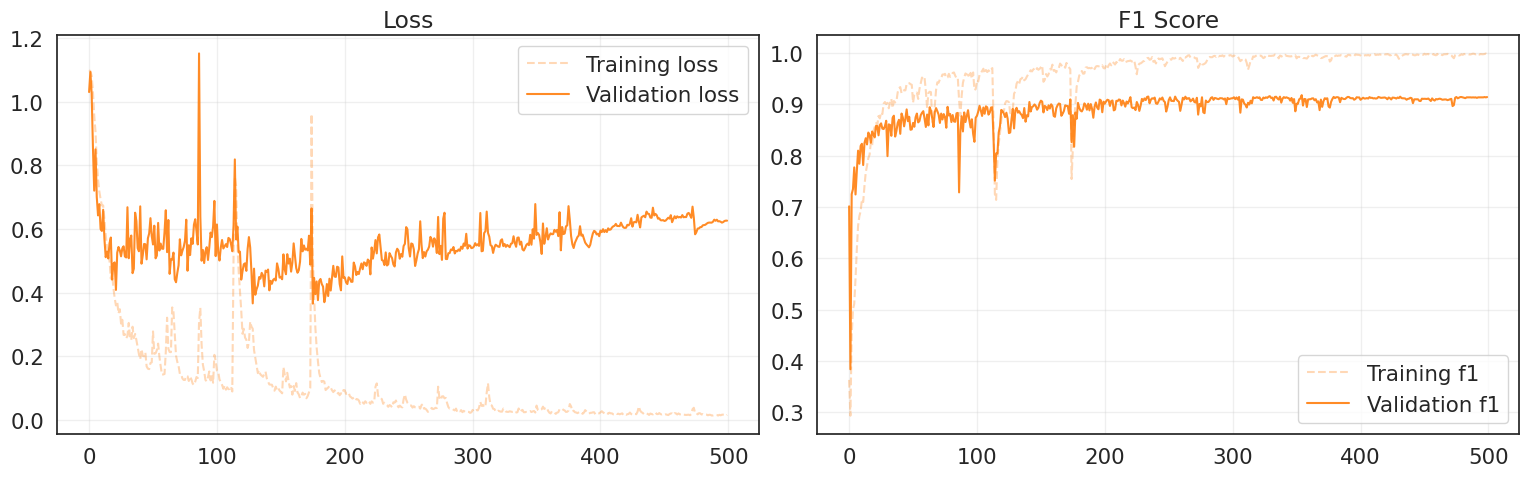

In [ ]:
# @title Plot History
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.8174
Precision over the validation set: 0.8514
Recall over the validation set: 0.8174
F1 score over the validation set: 0.8301


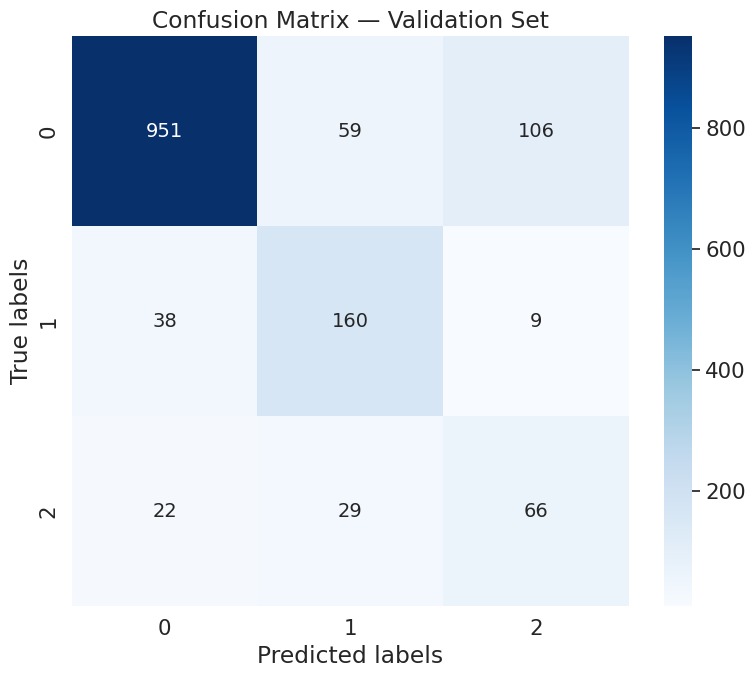

In [ ]:
# @title ## CONFUSION MATRIX CONSIDERING WINDOWS
# Collect predictions and ground truth labels
val_preds, val_targets = [], []
with torch.no_grad():  # Disable gradient computation for inference
    for xb, yb, _ in val_loader:  # Ignora sample_ids_batch
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualise confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()


Pirate-level Accuracy: 0.8438
Pirate-level Precision: 0.8725
Pirate-level Recall: 0.8438
Pirate-level F1 score: 0.8541
Total pirates evaluated: 160


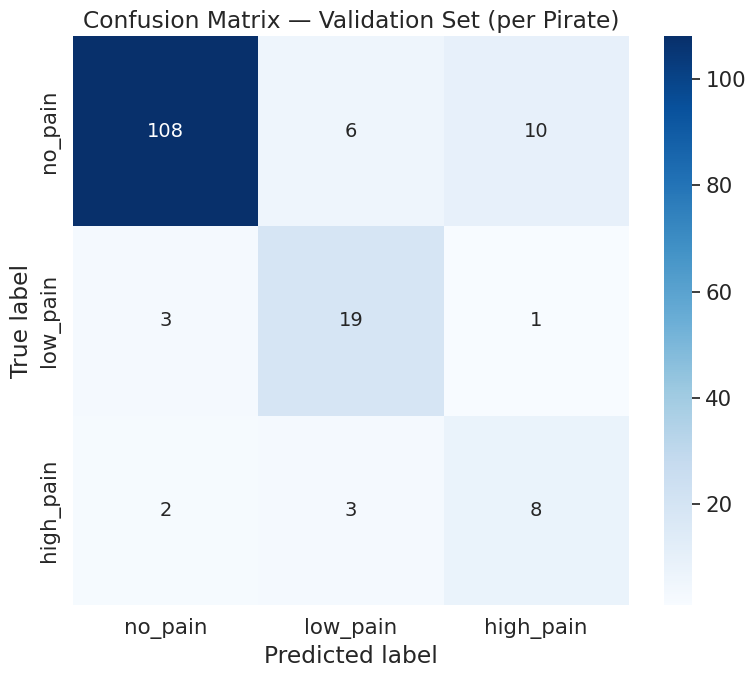

In [ ]:
# @title ## CONFUSION MATRIX CONSIDERING PIRATES
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Initialize dictionaries to store predictions and true labels per pirate
pirate_preds = defaultdict(list)
pirate_targets = {}

# Collect predictions, true labels, and sample_ids from the validation loader
sequence_preds = []
sequence_labels = []
sequence_sample_ids = []

with torch.no_grad():
    for xb, yb, sample_ids_batch in val_loader:  # val_loader now returns 3 items: features, labels, sample_ids
        xb = xb.to(device)

        # Forward pass: get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store sequence-level results
        sequence_preds.extend(preds)
        sequence_labels.extend(yb.numpy())
        sequence_sample_ids.extend(sample_ids_batch.numpy())

# Aggregate sequence-level predictions to pirate-level predictions using majority voting
for i in range(len(sequence_sample_ids)):
    pirate_id = sequence_sample_ids[i]
    pirate_preds[pirate_id].append(sequence_preds[i])

    # Store the true label for each pirate. Assuming consistent true label across sequences for a pirate.
    # If a pirate's true label is needed from the original df_val, that would be more robust.
    # For now, we take the true label from the first sequence encountered for that pirate.
    if pirate_id not in pirate_targets:
        pirate_targets[pirate_id] = sequence_labels[i]

# Apply majority vote for each pirate
final_pirate_preds = []
final_pirate_labels = []

for pirate_id in sorted(pirate_preds.keys()): # Sort pirate_ids for consistent ordering
    preds_for_pirate = np.array(pirate_preds[pirate_id])
    # Use np.bincount to find the most frequent prediction (majority vote)
    if len(preds_for_pirate) > 0:
        majority_vote = np.bincount(preds_for_pirate).argmax()
        final_pirate_preds.append(majority_vote)
        final_pirate_labels.append(pirate_targets[pirate_id])

# Define class names for better visualization
class_names = ['no_pain', 'low_pain', 'high_pain']

# Generate the confusion matrix at the pirate level
cm = confusion_matrix(final_pirate_labels, final_pirate_preds, labels=[0, 1, 2])

# Calculate overall metrics for the pirate-level predictions
pirate_acc = accuracy_score(final_pirate_labels, final_pirate_preds)
pirate_prec = precision_score(final_pirate_labels, final_pirate_preds, average='weighted', zero_division=0)
pirate_rec = recall_score(final_pirate_labels, final_pirate_preds, average='weighted', zero_division=0)
pirate_f1 = f1_score(final_pirate_labels, final_pirate_preds, average='weighted', zero_division=0)

print(f"\nPirate-level Accuracy: {pirate_acc:.4f}")
print(f"Pirate-level Precision: {pirate_prec:.4f}")
print(f"Pirate-level Recall: {pirate_rec:.4f}")
print(f"Pirate-level F1 score: {pirate_f1:.4f}")
print(f"Total pirates evaluated: {len(final_pirate_labels)}")

# Visualize the confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Validation Set (per Pirate)")
plt.tight_layout()
plt.show()

<br> <br>

## TEST THE RESULTS ON THE TESTING SET

In [ ]:
test_sequence_preds = []
test_sequence_labels = []
test_sequence_sample_ids = []

with torch.no_grad():
    for xb, yb, sample_ids_batch in test_loader:
        xb = xb.to(device)

        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        test_sequence_preds.extend(preds)
        test_sequence_labels.extend(yb.numpy())
        test_sequence_sample_ids.extend(sample_ids_batch.numpy())

from collections import defaultdict

test_pirate_preds = defaultdict(list)
test_pirate_targets = {}

for i in range(len(test_sequence_sample_ids)):
    pid = test_sequence_sample_ids[i]
    test_pirate_preds[pid].append(test_sequence_preds[i])

    if pid not in test_pirate_targets:
        test_pirate_targets[pid] = test_sequence_labels[i]

final_test_preds = []
final_test_labels = []

for pid in sorted(test_pirate_preds.keys()):
    votes = np.bincount(test_pirate_preds[pid]).argmax()
    final_test_preds.append(votes)
    final_test_labels.append(test_pirate_targets[pid])

# Define the label_map here
label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}

# Crea un DataFrame di confronto
results_df = pd.DataFrame({
    'true_label': final_test_labels,
    'pred_label': final_test_preds
})
results_df['true_label_name'] = results_df['true_label'].map(label_map)
results_df['pred_label_name'] = results_df['pred_label'].map(label_map)


# ==============================================================
#                TEST SET EVALUATION RESULTS (PER PIRATE)
# ==============================================================

# Calcolo metriche globali
test_accuracy = accuracy_score(results_df['true_label'], results_df['pred_label'])
test_precision = precision_score(results_df['true_label'], results_df['pred_label'], average='weighted', zero_division=0)
test_recall = recall_score(results_df['true_label'], results_df['pred_label'], average='weighted', zero_division=0)
test_f1 = f1_score(results_df['true_label'], results_df['pred_label'], average='weighted', zero_division=0)

print("=" * 60)
print("               TEST SET EVALUATION RESULTS")
print("=" * 60)
print(f"Overall Test Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Overall Test Precision: {test_precision:.4f}")
print(f"Overall Test Recall:    {test_recall:.4f}")
print(f"Overall Test F1 Score:  {test_f1:.4f}")
print()

# ==============================================================
#                PER-CLASS PERFORMANCE
# ==============================================================

class_names = ['no_pain', 'low_pain', 'high_pain']
class_ids = [0, 1, 2]

test_precision_per_class = precision_score(
    results_df['true_label'], results_df['pred_label'],
    average=None, labels=class_ids, zero_division=0
)
test_recall_per_class = recall_score(
    results_df['true_label'], results_df['pred_label'],
    average=None, labels=class_ids, zero_division=0
)
test_f1_per_class = f1_score(
    results_df['true_label'], results_df['pred_label'],
    average=None, labels=class_ids, zero_division=0
)

print("Per-Class Performance:")
print("-" * 40)
for i, class_name in enumerate(class_names):
    print(f"{class_name:>10}: Precision={test_precision_per_class[i]:.4f}, "
          f"Recall={test_recall_per_class[i]:.4f}, "
          f"F1={test_f1_per_class[i]:.4f}")
print()

# ==============================================================
#                PREDICTION DISTRIBUTION
# ==============================================================

unique_preds, pred_counts = np.unique(results_df['pred_label'], return_counts=True)
unique_targets, target_counts = np.unique(results_df['true_label'], return_counts=True)

print("Prediction Distribution (Predicted vs Actual):")
print("-" * 45)
for class_id, class_name in zip(class_ids, class_names):
    pred_count = pred_counts[unique_preds.tolist().index(class_id)] if class_id in unique_preds else 0
    true_count = target_counts[unique_targets.tolist().index(class_id)] if class_id in unique_targets else 0
    print(f"{class_name:>10}: Predicted={pred_count:3d}, Actual={true_count:3d}")

print("=" * 60)

# Show the distribution of correct predictions vs uncorrect predictions for each class
print("\n🎯 Correct vs Uncorrect per class:")
print("-" * 45)

for class_id, class_name in zip(class_ids, class_names):
    subset = results_df[results_df['true_label'] == class_id]

    total = len(subset)
    correct = (subset['true_label'] == subset['pred_label']).sum()
    incorrect = total - correct
    perc_correct = 100 * correct / total if total > 0 else 0

    print(f"{class_name:>10}: "
          f"Correct={correct:3d} / Uncorrect={incorrect:3d} "
          f"({perc_correct:5.1f}% correct)")


               TEST SET EVALUATION RESULTS
Overall Test Accuracy:  0.6667 (66.67%)
Overall Test Precision: 1.0000
Overall Test Recall:    0.6667
Overall Test F1 Score:  0.7778

Per-Class Performance:
----------------------------------------
   no_pain: Precision=1.0000, Recall=0.5000, F1=0.6667
  low_pain: Precision=1.0000, Recall=1.0000, F1=1.0000
 high_pain: Precision=0.0000, Recall=0.0000, F1=0.0000

Prediction Distribution (Predicted vs Actual):
---------------------------------------------
   no_pain: Predicted=  1, Actual=  2
  low_pain: Predicted=  1, Actual=  1
 high_pain: Predicted=  1, Actual=  0

🎯 Correct vs Uncorrect per class:
---------------------------------------------
   no_pain: Correct=  1 / Uncorrect=  1 ( 50.0% correct)
  low_pain: Correct=  1 / Uncorrect=  0 (100.0% correct)
 high_pain: Correct=  0 / Uncorrect=  0 (  0.0% correct)


<br> <br>  <br>

## K-fold Cross-Validation

In [190]:
df_train.shape, df_val.shape

((105760, 24), (14400, 24))

In [281]:
from sklearn.model_selection import StratifiedKFold

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

# Concatenate df_train with df_val
df_train = pd.concat([df_train, df_val], ignore_index=True)

users = df_train['sample_index'].unique()
labels_per_user = df_train.groupby('sample_index')['label'].first().values  # label di ciascun pirata

history_losses = {}
history_metrics = {}
fold_f1_scores = {}

fold = 1
for train_idx, val_idx in skf.split(users, labels_per_user):
    train_users_fold = users[train_idx]
    val_users_fold   = users[val_idx]

    if fold == 1:
        print("=== Distribuzione label nel primo fold ===")
        print("Train fold:")
        print(df_train[df_train['sample_index'].isin(train_users_fold)]['label'].value_counts(normalize=True))
        print("Validation fold:")
        print(df_train[df_train['sample_index'].isin(val_users_fold)]['label'].value_counts(normalize=True))
        print("========================================")

    df_train_fold = df_train[df_train['sample_index'].isin(train_users_fold)]
    df_val_fold   = df_train[df_train['sample_index'].isin(val_users_fold)]

    # ---- 2) Build sequences ----
    X_train_fold, y_train_fold, _ = build_sequences(df_train_fold, WINDOW_SIZE, STRIDE)
    X_val_fold, y_val_fold, _     = build_sequences(df_val_fold, WINDOW_SIZE, STRIDE)
    X_test_fold, y_test_fold   = X_test, y_test   # test set è SEMPRE lo stesso

    # ---- 3) Dataloaders ----
    train_ds_fold = TensorDataset(
        torch.tensor(X_train_fold, dtype=torch.float32),
        torch.tensor(y_train_fold, dtype=torch.long)
    )

    val_ds_fold   = TensorDataset(
        torch.tensor(X_val_fold, dtype=torch.float32),
        torch.tensor(y_val_fold, dtype=torch.long)
    )

    test_ds_fold  = TensorDataset(
        torch.tensor(X_test_fold, dtype=torch.float32),
        torch.tensor(y_test_fold, dtype=torch.long)
    )

    train_loader_fold = make_loader(train_ds_fold, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader_fold   = make_loader(val_ds_fold,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    test_loader_fold  = make_loader(test_ds_fold,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    # ---- 4) Ricrea modello da zero ----
    model = RecurrentClassifier(
        input_size=input_shape[-1],
        hidden_size=HIDDEN_SIZE,
        num_layers=HIDDEN_LAYERS,
        num_classes=num_classes,
        dropout_rate=DROPOUT_RATE,
        bidirectional=BIDIRECTIONAL,
        rnn_type=RNN_TYPE
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

    from torch.optim.lr_scheduler import ReduceLROnPlateau

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.7,
        patience=25,
        min_lr=1e-6
    )

    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

    # ---- 5) Train ----
    best_model_cp, history = fit(
        model=model,
        train_loader=train_loader_fold,
        val_loader=val_loader_fold,
        epochs=EPOCHS,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        writer=None,
        verbose=1,
        experiment_name=f"fold_{fold}",
        patience=PATIENCE,
        scheduler=scheduler
    )

    # Save the fold model (custom-selected)
    torch.save(model.state_dict(), f"{models_dir}/model_fold_{fold}.pt")

    # Save hystory
    history_losses[f'fold_{fold}']  = history['val_loss']
    history_metrics[f'fold_{fold}'] = history['val_f1']

    # F1 of the selected model
    fold_f1 = best_model_cp["val_f1"]
    fold_f1_scores[fold] = fold_f1

    print(f"\n>>> F1 of the fold {fold} (custom model selected): {fold_f1:.4f}\n")

    fold += 1


=== Distribuzione label nel primo fold ===
Train fold:
label
0    0.778409
1    0.134470
2    0.087121
Name: proportion, dtype: float64
Validation fold:
label
0    0.751880
1    0.172932
2    0.075188
Name: proportion, dtype: float64
Training 500 epochs...
Epoch   1/500 | Train: Loss=0.3064, F1 Score=0.6789 | Val: Loss=0.2740, F1 Score=0.6454 | LR=0.001000
Epoch   2/500 | Train: Loss=0.2649, F1 Score=0.6814 | Val: Loss=0.2763, F1 Score=0.6454 | LR=0.001000
Epoch   3/500 | Train: Loss=0.2568, F1 Score=0.6814 | Val: Loss=0.2693, F1 Score=0.6454 | LR=0.001000
Epoch   4/500 | Train: Loss=0.2462, F1 Score=0.6814 | Val: Loss=0.2717, F1 Score=0.6454 | LR=0.001000
Epoch   5/500 | Train: Loss=0.2338, F1 Score=0.6814 | Val: Loss=0.2505, F1 Score=0.6465 | LR=0.001000
Epoch   6/500 | Train: Loss=0.2193, F1 Score=0.7215 | Val: Loss=0.2444, F1 Score=0.6564 | LR=0.001000
Epoch   7/500 | Train: Loss=0.2102, F1 Score=0.7423 | Val: Loss=0.2367, F1 Score=0.6809 | LR=0.001000
Epoch   8/500 | Train: Loss=0

KeyboardInterrupt: 

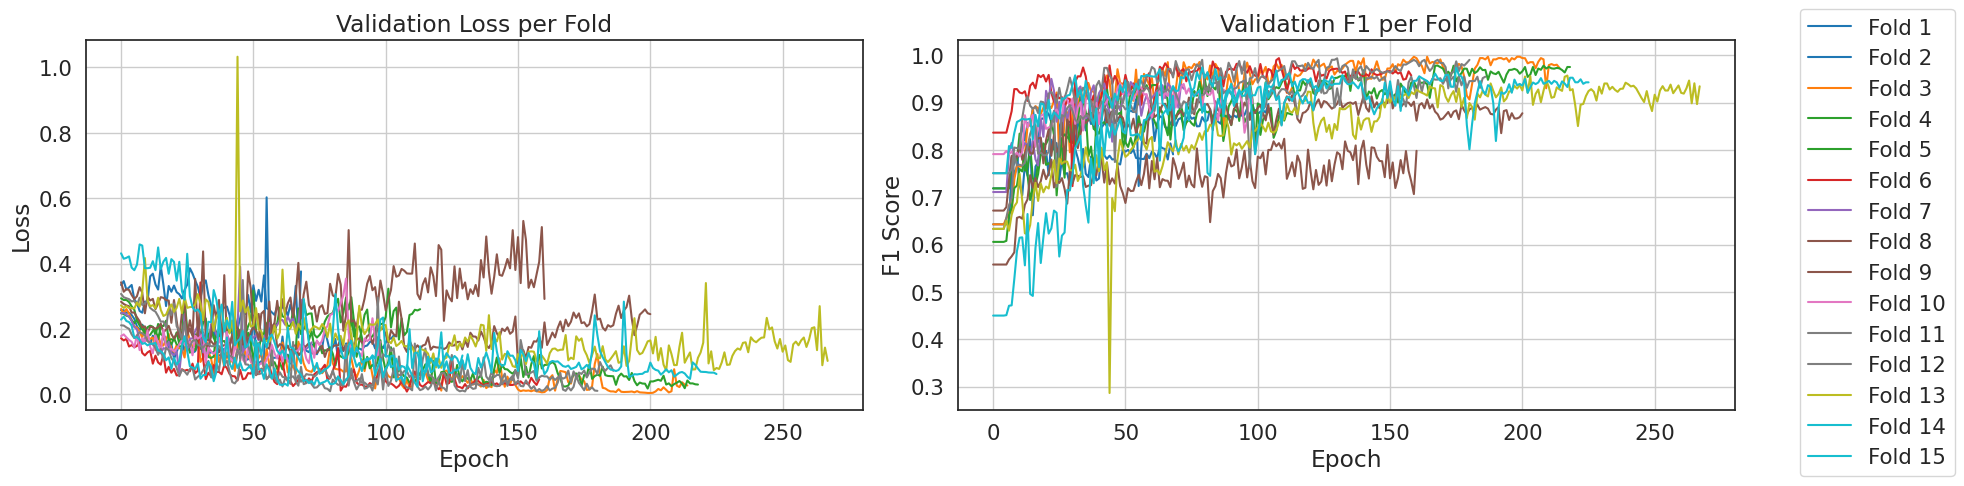

In [ ]:
# @title K-fold Plot History

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)
colors = plt.cm.get_cmap('tab10', K)

# Plot validation loss
for i in range(1, K+1):
    axes[0].plot(history_losses[f'fold_{i}'], label=f'Fold {i}', color=colors(i-1))
axes[0].set_title("Validation Loss per Fold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# Plot validation F1
for i in range(1, K+1):
    axes[1].plot(history_metrics[f'fold_{i}'], label=f'Fold {i}', color=colors(i-1))
axes[1].set_title("Validation F1 per Fold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.subplots_adjust(right=0.97)
plt.show()



Starting final prediction for 1324 pirates


Using 11/15 folds for prediction
 - fold 3 with F1 = 0.9970
 - fold 4 with F1 = 0.9781
 - fold 6 with F1 = 0.9940
 - fold 7 with F1 = 0.9502
 - fold 9 with F1 = 0.9365
 - fold 10 with F1 = 0.9394
 - fold 11 with F1 = 0.9905
 - fold 12 with F1 = 0.9517
 - fold 13 with F1 = 0.9546
 - fold 14 with F1 = 0.9744
 - fold 15 with F1 = 0.9710

Submission file 'LSTM_bi_16-11-13-22.csv' created
Number of rows = 1324 (should be = 1324)
   sample_index prediction
0             0    no_pain
1             1    no_pain
2             2    no_pain
3             3    no_pain
4             4    no_pain

Class distribution:
no_pain   : 80.21%
low_pain  : 13.52%
high_pain :  6.27%


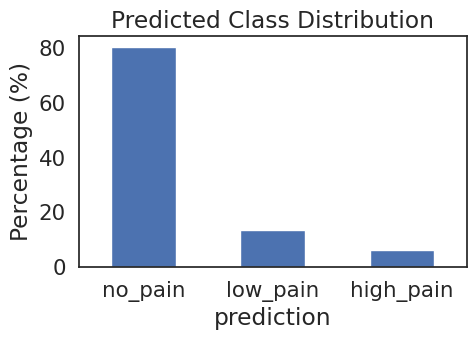

In [ ]:
label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}

final_results = []

print(f"\nStarting final prediction for {X_test_final_df['sample_index'].nunique()} pirates\n")

# ==========================
# SELECT BEST FOLDS ACCORDING TO F1 SCORE
# ==========================

# Use folds with F1 score >= a chosen % less, with respect to the best F1 score
best_f1_overall = max(fold_f1_scores.values())
f1_threshold = best_f1_overall * 0.92
eligible_folds = [fold for fold, f1 in fold_f1_scores.items() if f1 >= f1_threshold]

print(f"\nUsing {len(eligible_folds)}/{K} folds for prediction")
for f in eligible_folds:
    print(f" - fold {f} with F1 = {fold_f1_scores[f]:.4f}")

if len(eligible_folds) == 0:
    raise ValueError("No folds above the threshold")


# --- LOOP su ogni PIRATA (sample_index) ---
for sample_id in sorted(X_test_final_df['sample_index'].unique()):

    temp = X_test_final_df[X_test_final_df['sample_index'] == sample_id]

    # Padding se il pirata ha meno di WINDOW_SIZE righe
    if len(temp) < WINDOW_SIZE:
        padding = pd.DataFrame(0, index=np.arange(WINDOW_SIZE - len(temp)), columns=temp.columns)
        temp = pd.concat([temp, padding], ignore_index=True)

    # Genera sequenze del pirata
    seqs = build_sequences_test(temp, window=WINDOW_SIZE, stride=STRIDE)

    # Se build_sequences_test restituisce 0 finestre
    if len(seqs) == 0:
        seqs = temp.iloc[-WINDOW_SIZE:].values[np.newaxis, :, :]

    seqs = np.nan_to_num(seqs)
    seqs_tensor = torch.tensor(seqs, dtype=torch.float32).to(device)

    # --- Predizioni K-fold ---
    kfold_preds_per_sequence = []

    for fold in eligible_folds:

        model = RecurrentClassifier(
            input_size=seqs.shape[-1],
            hidden_size=HIDDEN_SIZE,
            num_layers=HIDDEN_LAYERS,
            num_classes=len(label_map),
            dropout_rate=DROPOUT_RATE,
            bidirectional=BIDIRECTIONAL,
            rnn_type=RNN_TYPE
        ).to(device)

        model.load_state_dict(torch.load(f"{models_dir}/model_fold_{fold}.pt", map_location=device))
        model.eval()

        with torch.no_grad():
            logits = model(seqs_tensor)
            preds = logits.argmax(dim=1).cpu().numpy()

        kfold_preds_per_sequence.append(preds)

    kfold_preds_per_sequence = np.array(kfold_preds_per_sequence)

    # --- Majority voting per sequence ---
    def majority_highest_class(x):
        counts = np.bincount(x, minlength=3)  # 3 classes
        return np.where(counts == counts.max())[0].max()  # tie-break towards the highest class (prefer high_pain, then low_pain)

    majority_per_sequence = np.apply_along_axis(
        majority_highest_class,
        axis=0,
        arr=kfold_preds_per_sequence
    )


    # --- Majority voting finale per pirata ---
    counts = np.bincount(majority_per_sequence, minlength=3)
    final_class = np.where(counts == counts.max())[0].max()


    final_results.append({
        "sample_index": int(sample_id),
        "prediction": label_map[final_class]
    })

# --- Crea submission ---
submission = pd.DataFrame(final_results)
submission.to_csv(SUBMISSION_FILENAME, index=False)

print(f"\nSubmission file '{SUBMISSION_FILENAME}' created")
print(f"Number of rows = {len(submission)} (should be = 1324)")
print(submission.head())

print("\nClass distribution:")
label_counts = submission['prediction'].value_counts(normalize=True) * 100
for label in ['no_pain','low_pain','high_pain']:
    print(f"{label:10s}: {label_counts.get(label,0):5.2f}%")

# Visualize as a bar chart
# import matplotlib.pyplot as plt
desired_order = ["no_pain", "low_pain", "high_pain"]
label_counts_ordered = label_counts.reindex(desired_order)
plt.figure(figsize=(5,3))
(label_counts_ordered
 .plot(kind='bar', rot=0, title='Predicted Class Distribution', ylabel='Percentage (%)'))
plt.show()


## Test results on the validation set (k-fold employs just df_train)

In [ ]:
val_sequence_preds = []
val_sequence_labels = []
val_sequence_sample_ids = []

# Creiamo un DataLoader per df_val
X_val_full, y_val_full, sample_ids_val = build_sequences(df_val, WINDOW_SIZE, STRIDE)
val_ds = TensorDataset(
    torch.tensor(X_val_full, dtype=torch.float32),
    torch.tensor(y_val_full, dtype=torch.long),
    torch.tensor(sample_ids_val, dtype=torch.long)
)
val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

with torch.no_grad():
    for xb, yb, sample_ids_batch in val_loader:
        xb = xb.to(device)

        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        val_sequence_preds.extend(preds)
        val_sequence_labels.extend(yb.numpy())
        val_sequence_sample_ids.extend(sample_ids_batch.numpy())

from collections import defaultdict

val_pirate_preds = defaultdict(list)
val_pirate_targets = {}

for i in range(len(val_sequence_sample_ids)):
    pid = val_sequence_sample_ids[i]
    val_pirate_preds[pid].append(val_sequence_preds[i])

    if pid not in val_pirate_targets:
        val_pirate_targets[pid] = val_sequence_labels[i]

final_val_preds = []
final_val_labels = []

for pid in sorted(val_pirate_preds.keys()):
    votes = np.bincount(val_pirate_preds[pid]).argmax()  # majority voting per pirate
    final_val_preds.append(votes)
    final_val_labels.append(val_pirate_targets[pid])

# Define the label_map
label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}

# DataFrame dei risultati
results_df = pd.DataFrame({
    'true_label': final_val_labels,
    'pred_label': final_val_preds
})
results_df['true_label_name'] = results_df['true_label'].map(label_map)
results_df['pred_label_name'] = results_df['pred_label'].map(label_map)

# =============================================================
#                VALIDATION SET EVALUATION
# =============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

val_accuracy = accuracy_score(results_df['true_label'], results_df['pred_label'])
val_precision = precision_score(results_df['true_label'], results_df['pred_label'], average='weighted', zero_division=0)
val_recall = recall_score(results_df['true_label'], results_df['pred_label'], average='weighted', zero_division=0)
val_f1 = f1_score(results_df['true_label'], results_df['pred_label'], average='weighted', zero_division=0)

print("=" * 60)
print("            VALIDATION SET EVALUATION RESULTS")
print("=" * 60)
print(f"Accuracy:  {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"F1 Score:  {val_f1:.4f}")
print()

# =============================================================
#                PER-CLASS PERFORMANCE
# =============================================================
class_names = ['no_pain', 'low_pain', 'high_pain']
class_ids = [0, 1, 2]

val_precision_per_class = precision_score(results_df['true_label'], results_df['pred_label'], average=None, labels=class_ids, zero_division=0)
val_recall_per_class = recall_score(results_df['true_label'], results_df['pred_label'], average=None, labels=class_ids, zero_division=0)
val_f1_per_class = f1_score(results_df['true_label'], results_df['pred_label'], average=None, labels=class_ids, zero_division=0)

print("Per-Class Performance:")
for i, class_name in enumerate(class_names):
    print(f"{class_name:>10}: Precision={val_precision_per_class[i]:.4f}, "
          f"Recall={val_recall_per_class[i]:.4f}, "
          f"F1={val_f1_per_class[i]:.4f}")
print()


# Save model configuration

In [ ]:
# Gather all relevant model and training parameters
model_config = {
    'EXPERIMENT_NAME': EXPERIMENT_NAME,
    'RNN_TYPE': RNN_TYPE,
    'BIDIRECTIONAL': BIDIRECTIONAL,
    'input_size': input_shape[-1],
    'num_classes': num_classes,
    'HIDDEN_SIZE': HIDDEN_SIZE,
    'HIDDEN_LAYERS': HIDDEN_LAYERS,
    'DROPOUT_RATE': DROPOUT_RATE,
    'LEARNING_RATE': LEARNING_RATE,
    'EPOCHS': EPOCHS,
    'PATIENCE': PATIENCE,
    'L1_LAMBDA': L1_LAMBDA,
    'L2_LAMBDA': L2_LAMBDA,
    'BATCH_SIZE': BATCH_SIZE,
    'WINDOW_SIZE': WINDOW_SIZE,
    'STRIDE': STRIDE,
    'SEED': SEED,
    'one_pirate_window': one_pirate_window,
    # 'TEST_F1': f'{test_f1:.4f}'
}

# Define the path to save the config file
config_filepath = os.path.join(models_dir, f"{EXPERIMENT_NAME}_config.json")

# Save the dictionary as a JSON file
with open(config_filepath, 'w') as f:
    json.dump(model_config, f, indent=4)

print(f"✅ Model configuration saved to '{config_filepath}'")

# Display the saved configuration
print("\n--- Saved Model Configuration ---")
print(json.dumps(model_config, indent=4))
print("-----------------------------------")

✅ Model configuration saved to 'models/LSTM_bi_16-11-13-22_config.json'

--- Saved Model Configuration ---
{
    "EXPERIMENT_NAME": "LSTM_bi_16-11-13-22",
    "RNN_TYPE": "LSTM",
    "BIDIRECTIONAL": true,
    "input_size": 21,
    "num_classes": 3,
    "HIDDEN_SIZE": 132,
    "HIDDEN_LAYERS": 2,
    "DROPOUT_RATE": 0.3,
    "LEARNING_RATE": 0.001,
    "EPOCHS": 500,
    "PATIENCE": 50,
    "L1_LAMBDA": 1e-06,
    "L2_LAMBDA": 0.001,
    "BATCH_SIZE": 512,
    "WINDOW_SIZE": 68,
    "STRIDE": 17,
    "SEED": 42,
    "one_pirate_window": true
}
-----------------------------------


# <br> <br> <br> <br>

## GRID SEARCH: HYPERPARAMETERS TUNING

In [ ]:
from sklearn.model_selection import ParameterGrid
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time, copy, math

GRID_EPOCHS   = 500
GRID_PATIENCE = 40

param_grid = {
    'RNN_TYPE': ['LSTM'],
    'BIDIRECTIONAL': [True],
    'HIDDEN_SIZE': [126, 128, 130, 132, 134],
    'HIDDEN_LAYERS': [2],
    'LEARNING_RATE': [1e-3],
    'DROPOUT_RATE': [0.3],
    'BATCH_SIZE': [512],
    'L1_LAMBDA': [1e-6],
    'L2_LAMBDA': [1e-3],
    'WINDOW': [68],
    'STRIDE': [17],
    'CRITERION': ['FOCAL'],         # or CROSS
    #'WEIGHTS': [[1.0, 1.0, 1.0]],  # Used only for CrossEntropy
    'GAMMA': [2.2],       # Used only for Focal
}

grid = list(ParameterGrid(param_grid))
print(f"\nRunning {len(grid)} configurations...")

results = []

best_val_f1 = float('-inf')
best_params = None
best_state_dict = None
best_run_idx = None
best_epoch_in_run = None
best_training_history = None


Running 5 configurations...


## Loop the grid

In [ ]:
for idx, params in enumerate(grid, start=1):

    print(f"\n--- Configuration {idx}/{len(grid)} ---")
    t0 = time.perf_counter()

    # ================
    # 1) BUILD SEQUENCES
    # ================
    WINDOW_GRID = params['WINDOW']
    STRIDE_GRID = params['STRIDE']

    X_train, y_train, _ = build_sequences(df_train, WINDOW_GRID, STRIDE_GRID)
    X_val,   y_val,   _ = build_sequences(df_val,   WINDOW_GRID, STRIDE_GRID)

    X_train = X_train.astype('float32')
    X_val   = X_val.astype('float32')

    input_shape = X_train.shape[1:]
    num_classes = len(np.unique(y_train))

    # ======================
    # 2) DATALOADERS
    # ======================
    train_ds = TensorDataset(
        torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long)
    )
    val_ds = TensorDataset(
        torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long)
    )

    train_loader = make_loader(train_ds, batch_size=params['BATCH_SIZE'], shuffle=True, drop_last=False)
    val_loader   = make_loader(val_ds,   batch_size=params['BATCH_SIZE'], shuffle=False, drop_last=False)

    # ======================
    # 3) CRITERION
    # ======================
    if params["CRITERION"] == "CROSS":
        weights = torch.tensor(params["WEIGHTS"], dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=weights)
    else:
        criterion = FocalLoss(alpha=None, gamma=params["GAMMA"])

    # ======================
    # 4) MODEL BUILD
    # ======================
    model = RecurrentClassifier(
        input_size=input_shape[-1],
        hidden_size=params["HIDDEN_SIZE"],
        num_layers=params["HIDDEN_LAYERS"],
        dropout_rate=params["DROPOUT_RATE"],
        bidirectional=params["BIDIRECTIONAL"],
        rnn_type=params["RNN_TYPE"],
        num_classes=num_classes
    ).to(device)

    # ======================
    # 5) OPTIMIZER + SCHEDULER
    # ======================
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params["LEARNING_RATE"],
        weight_decay=params["L2_LAMBDA"]
    )

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.7,
        patience=25,
        min_lr=1e-6
    )

    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

    # ======================
    # 6) TRAIN
    # ======================
    try:
        model, history, best_model_cp = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=GRID_EPOCHS,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            l1_lambda=params["L1_LAMBDA"],
            l2_lambda=0.0,                 # L2 già nell'optimizer
            patience=GRID_PATIENCE,
            experiment_name=f"grid_run_{idx}",
            writer=None,
            scheduler=scheduler
        )

        # ======================
        # 7) EVALUATION
        # ======================
        val_f1_series = history["val_f1"]
        train_f1_series = history["train_f1"]
        val_loss_series = history["val_loss"]
        train_loss_series = history["train_loss"]

        best_f1 = max(val_f1_series)
        best_epoch = val_f1_series.index(best_f1) + 1

        best_train_f1 = max(train_f1_series)
        min_val_loss = min(val_loss_series)
        min_train_loss = min(train_loss_series)

        print(f"✓ Run {idx}: best F1={best_f1:.4f} @ epoch {best_epoch}")

        results.append({
            **params,
            "Run": idx,
            "Best_Epoch": best_epoch,
            "Best_Val_F1": best_f1,
            "Best_Train_F1": best_train_f1,
            "Min_Val_Loss": min_val_loss,
            "Min_Train_Loss": min_train_loss
        })

        # Track global best
        if best_f1 > best_val_f1:
            best_val_f1 = best_f1
            best_params = params
            best_state_dict = copy.deepcopy(model.state_dict())
            best_run_idx = idx
            best_epoch_in_run = best_epoch
            best_training_history = history


    except Exception as e:
        print(f"[ERROR] Run {idx} failed: {e}")

    finally:
        del model, optimizer, scaler
        if device.type == 'cuda':
            torch.cuda.empty_cache()

    print(f"Completed in {(time.perf_counter() - t0):.1f}s")

    print("\n================ GRID SEARCH COMPLETE ================")

print(f"Best run #{best_run_idx} | epoch {best_epoch_in_run}")
print(f"Best F1: {best_val_f1:.4f}")
print("Best Params:", best_params)

df_results = pd.DataFrame(results).sort_values("Best_Val_F1", ascending=False)
df_results.reset_index(drop=True, inplace=True)

save_dir = "/gdrive/My Drive/AN2DL Challenge 1/Grid search"
os.makedirs(save_dir, exist_ok=True)   # check if the folder exists

# generate timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# complete path
save_path = os.path.join(save_dir, f"grid_results_{timestamp}.csv")

# save csv
df_results.to_csv(save_path, index=False)
print(f"file CSV salvato in: {save_path}")
df_results


--- Configuration 1/5 ---
Training 500 epochs...
Epoch   1/500 | Train: Loss=0.3327, F1 Score=0.6728 | Val: Loss=0.2642, F1 Score=0.6794 | LR=0.001000
Epoch  10/500 | Train: Loss=0.2145, F1 Score=0.7855 | Val: Loss=0.2463, F1 Score=0.7679 | LR=0.001000
Epoch  20/500 | Train: Loss=0.2000, F1 Score=0.7832 | Val: Loss=0.2221, F1 Score=0.7677 | LR=0.001000
Epoch  30/500 | Train: Loss=0.1369, F1 Score=0.8570 | Val: Loss=0.1667, F1 Score=0.8053 | LR=0.001000
Epoch  40/500 | Train: Loss=0.0946, F1 Score=0.9047 | Val: Loss=0.1586, F1 Score=0.8354 | LR=0.001000
Epoch  50/500 | Train: Loss=0.1141, F1 Score=0.8772 | Val: Loss=0.1797, F1 Score=0.8514 | LR=0.001000
Epoch  60/500 | Train: Loss=0.0702, F1 Score=0.9288 | Val: Loss=0.1454, F1 Score=0.8751 | LR=0.001000
Epoch  70/500 | Train: Loss=0.0664, F1 Score=0.9292 | Val: Loss=0.1798, F1 Score=0.8822 | LR=0.001000
Epoch  80/500 | Train: Loss=0.0753, F1 Score=0.9290 | Val: Loss=0.1281, F1 Score=0.8928 | LR=0.001000
Epoch  90/500 | Train: Loss=0.04

,BATCH_SIZE,BIDIRECTIONAL,CRITERION,DROPOUT_RATE,GAMMA,HIDDEN_LAYERS,HIDDEN_SIZE,L1_LAMBDA,L2_LAMBDA,LEARNING_RATE,RNN_TYPE,STRIDE,WINDOW,Run,Best_Epoch,Best_Val_F1,Best_Train_F1,Min_Val_Loss,Min_Train_Loss
0,512,True,FOCAL,0.3,2.2,2,126,0.000001,0.001,0.001,LSTM,17,68,1,153,0.921869,0.986806,0.124958,0.021876
1,512,True,FOCAL,0.3,2.2,2,132,0.000001,0.001,0.001,LSTM,17,68,4,61,0.919014,0.982328,0.097124,0.025777
2,512,True,FOCAL,0.3,2.2,2,130,0.000001,0.001,0.001,LSTM,17,68,3,118,0.912737,0.982387,0.091694,0.023579
3,512,True,FOCAL,0.3,2.2,2,128,0.000001,0.001,0.001,LSTM,17,68,2,110,0.910539,0.973601,0.138461,0.029009
4,512,True,FOCAL,0.3,2.2,2,134,0.000001,0.001,0.001,LSTM,17,68,5,38,0.907411,0.944929,0.107399,0.062526


## Recap of results and Plots

In [ ]:
results = pd.read_csv(results_path)
print(results.to_string(index=False))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

plots = [
    ("L1_LAMBDA",     "Best Val F1 vs L1 Lambda"),
    ("L2_LAMBDA",     "Best Val F1 vs L2 Lambda"),
    ("STRIDE",        "Best Val F1 vs Stride"),
    ("WINDOW",        "Best Val F1 vs Window"),
    ("HIDDEN_SIZE",   "Best Val F1 vs Hidden Size"),
    ("HIDDEN_LAYERS", "Best Val F1 vs Hidden Layers"),
    ("DROPOUT_RATE",  "Best Val F1 vs Dropout Rate"),
    ("GAMMA",         "Best Val F1 vs Gamma"),
]

for i, (col, title) in enumerate(plots, 1):
    plt.subplot(4, 2, i)
    sns.lineplot(data=results, x=col, y='Best_Val_F1', marker='o')
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("F1")

plt.tight_layout()
plt.show()


<br>  <br> <br> <br> <br>

## 14 Competition Submission

In [ ]:
# Build sequences from the actual test data
print(f"Building sequences for actual test dataset with WINDOW_SIZE={WINDOW_SIZE}, STRIDE={STRIDE}")

X_test_sequences = build_sequences_test(X_test_final_df)

# Discard nan values from the dataset
if np.isnan(X_test_sequences).any():
    X_test_sequences = np.nan_to_num(X_test_sequences)
    print("NaN values found and replaced with 0 in test sequences.")


# Create a TensorDataset from the test sequences (no labels needed for prediction)
test_ds_final = TensorDataset(torch.from_numpy(X_test_sequences))

# Create a DataLoader for the final test set
test_loader_final = make_loader(test_ds_final, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Actual test sequences shape: {X_test_sequences.shape}")
print(f"Number of batches in final test loader: {len(test_loader_final)}")


# Create model with the correct input size (based on the feature columns used in sequences)
actual_input_size = X_test_sequences.shape[-1]
print(f"Model input size derived from test sequences: {actual_input_size}")

Building sequences for actual test dataset with WINDOW_SIZE=90, STRIDE=30
Actual test sequences shape: (1324, 200, 21)
Number of batches in final test loader: 3
Model input size derived from test sequences: 21


In [ ]:
# Show test_final
X_test_final_df

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_07,joint_08,joint_09,joint_10,joint_11,joint_12,joint_26,joint_27,joint_28,joint_29
0,0.0,0.0,1.0,1.0,1.0,1.0,0.561563,0.553352,0.419037,0.270175,...,0.654303,0.737832,0.742275,0.100076,0.146564,0.745300,0.014909,0.045098,0.012882,0.010178
1,0.0,1.0,1.0,1.0,1.0,1.0,0.599088,0.532067,0.461325,0.327922,...,0.684443,0.772454,0.710705,0.103457,0.174403,0.594262,0.053679,0.055375,0.013892,0.029085
2,0.0,2.0,1.0,1.0,1.0,1.0,0.638365,0.583960,0.445804,0.308796,...,0.676488,0.799646,0.722061,0.143175,0.159973,0.652024,0.042305,0.039620,0.016286,0.040638
3,0.0,3.0,0.5,1.0,1.0,1.0,0.554938,0.488719,0.443494,0.355023,...,0.650563,0.738087,0.709363,0.141007,0.167449,0.709558,0.037477,0.031101,0.008568,0.018730
4,0.0,4.0,1.0,1.0,1.0,0.0,0.537192,0.528780,0.413159,0.363199,...,0.653239,0.703021,0.681513,0.140234,0.186249,0.590142,0.015210,0.019426,0.008189,0.013444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211835,1323.0,155.0,1.0,1.0,0.5,1.0,0.746791,0.715951,0.787217,0.908019,...,0.746858,0.646380,0.606524,0.361932,0.515863,0.762767,0.009774,0.031095,0.006292,0.070267
211836,1323.0,156.0,0.5,1.0,1.0,1.0,0.712191,0.805042,0.749162,0.829449,...,0.741321,0.576658,0.647361,0.389554,0.471334,0.723960,0.027009,0.049113,0.029173,0.068884
211837,1323.0,157.0,0.5,1.0,1.0,1.0,0.778327,0.727727,0.775497,0.841656,...,0.762795,0.678090,0.628388,0.353318,0.453431,0.739291,0.025910,0.042127,0.011971,0.079291
211838,1323.0,158.0,1.0,1.0,0.5,1.0,0.740327,0.768988,0.749230,0.854667,...,0.694102,0.654149,0.611106,0.378361,0.497827,0.714944,0.052790,0.019468,0.015994,0.106760


Model input size derived from test sequences: 21
Model created with input_size=21, hidden_size=37
-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 200, 74], [4, -1, 37]] 51,208         
classifier (Linear)       [-1, 3]                      225            
Total params: 51,433
Trainable params: 51,433
Non-trainable params: 0
-------------------------------------------------------------------------------
✓ Model successfully loaded from models/LSTM_bi_13-11-23-57_model.pt
✓ Model loaded with 51,433 parameters
Starting inference on actual test set...
Running inference on 3 batches...
Batch input shape: torch.Size([512, 200, 21])
Expected: (batch_size, 68, 21)
Processed batch 3/3

Inference on actual test set completed successfully!
Total predictions: 1324
Predictions shape: (1324,)
Probabilities shape: (1324, 3)
   sample_index prediction
0           0.

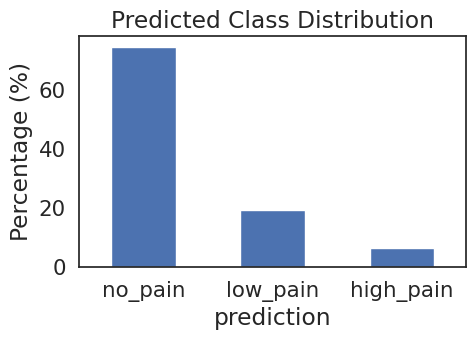

In [ ]:
print(f"Model input size derived from test sequences: {actual_input_size}")

rnn_model = RecurrentClassifier(
    input_size=actual_input_size,
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=BIDIRECTIONAL,
    rnn_type=RNN_TYPE
    ).to(device)

print(f"Model created with input_size={actual_input_size}, hidden_size={HIDDEN_SIZE}")
# It's good practice to summarize the model with the actual input shape it will receive
recurrent_summary(rnn_model, input_size=X_test_sequences.shape[1:])


# Load the trained model
model_path = MODEL_LOAD_PATH

try:
    # Load the state dict
    checkpoint = torch.load(model_path, map_location=device)
    rnn_model.load_state_dict(checkpoint)
    print(f"✓ Model successfully loaded from {model_path}")

    # Verify model architecture matches
    total_params = sum(p.numel() for p in rnn_model.parameters())
    print(f"✓ Model loaded with {total_params:,} parameters")

except FileNotFoundError:
    print(f"✗ ERROR: Model file not found at {model_path}")
    print("Please ensure the model was trained and saved properly.")
    print("You may need to retrain the model or check the file path.")
    # Exit or handle the error appropriately if the model cannot be loaded

except RuntimeError as e:
    print(f"✗ ERROR: Model architecture mismatch!")
    print(f"Error details: {str(e)}")
    print("\nThis usually happens when the saved model has a different architecture")
    print("than the current model definition (input_size, hidden_size, num_layers, bidirectional).")
    print("Please ensure the current model definition matches the saved model.")
    # Re-raise the exception after providing diagnostic information
    raise e


rnn_model.eval()  # Set model to evaluation mode

print("Starting inference on actual test set...")

# --- Inference Pipeline ---
final_test_preds = []
final_test_probabilities = []
sample_indices = []

print(f"Running inference on {len(test_loader_final)} batches...")

with torch.no_grad():  # Disable gradient computation for inference
    for batch_idx, inputs in enumerate(test_loader_final):
        # DataLoaders for prediction might return a tuple even with one tensor
        xb = inputs[0].to(device)

        # Verify batch dimensions
        if batch_idx == 0:
            print(f"Batch input shape: {xb.shape}")
            print(f"Expected: (batch_size, {WINDOW_SIZE}, {actual_input_size})")

        # Get model predictions
        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Get probabilities for confidence analysis
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()

        # Store batch results
        final_test_preds.append(preds)
        final_test_probabilities.append(probabilities)

        # Since test_loader_final is built from sequences, we need to map predictions back to original sample indices
        # The indices for this batch correspond to the sequences generated.
        # We'll need to figure out the mapping from sequence index to original sample_index later for the submission file.
        # For now, just store the predictions.

        # Progress indicator
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(test_loader_final):
            print(f"Processed batch {batch_idx + 1}/{len(test_loader_final)}")


# Combine all batches into single arrays
final_test_preds = np.concatenate(final_test_preds)
final_test_probabilities = np.concatenate(final_test_probabilities)

print(f"\nInference on actual test set completed successfully!")
print(f"Total predictions: {len(final_test_preds)}")
print(f"Predictions shape: {final_test_preds.shape}")
print(f"Probabilities shape: {final_test_probabilities.shape}")


# --- Create Submission File ---
# Map numerical predictions back to original labels
label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
pred_labels = [label_map[p] for p in final_test_preds]

# The sample_index for the submission file should correspond to the original sample_index from X_test_final_df
# Since build_sequences creates multiple sequences per sample_index (if stride < window),
# we need to associate each prediction with its original sample_index.
# A simple way is to assume each sequence corresponds to the sample_index it came from.
# This might not be perfectly accurate if predictions should be per-sample instead of per-sequence.
# For this submission, we'll create a submission row for each sequence prediction.

# Generate sample indices for the sequences
# The number of sequences is len(final_test_preds)
# We need to replicate the original sample_indices based on how many sequences were generated per sample.
# This requires re-running or adapting the logic from build_sequences to track original indices.

# A simpler approach for submission, if predictions are expected per original sample_index,
# is to average predictions per sample_index or take the majority vote.
# However, the competition usually expects one prediction per sequence/window if the model outputs per sequence.
# Let's assume the submission requires one prediction per sequence generated.

final_results = [] # Initialize final_results list

for sample_id in X_test_final_df['sample_index'].unique():

    # extract rows for this sample
    temp = X_test_final_df[X_test_final_df['sample_index'] == sample_id]

    # If the sample has fewer rows than WINDOW_SIZE, pad it with zeros
    if len(temp) < WINDOW_SIZE:
        padding = pd.DataFrame(0, index=np.arange(WINDOW_SIZE - len(temp)), columns=temp.columns)
        temp = pd.concat([temp, padding], ignore_index=True)

    # build sequences for this sample
    seqs = build_sequences_test(temp, window=WINDOW_SIZE, stride=STRIDE)  # shape: [num_windows, window, features]

    # sometimes build_sequences_test might still return zero sequences if len(temp) < stride
    if len(seqs) == 0:
        # fallback: take the last WINDOW_SIZE rows
        seqs = temp.iloc[-WINDOW_SIZE:].values[np.newaxis, :, :]

    seqs = torch.tensor(seqs, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = rnn_model(seqs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    # Final decision for this sample_index
    final_class = np.bincount(preds).argmax()  # majority vote
    final_results.append({
        "sample_index": sample_id,
        "prediction": label_map[final_class]
    })

submission = pd.DataFrame(final_results)
submission.to_csv(SUBMISSION_FILENAME, index=False)

print(submission.head())
print(f"✅ Saved submission with {len(submission)} rows should be 1324")

# --- Analyze class distribution in final predictions ---
label_counts = submission['prediction'].value_counts(normalize=True) * 100

print("\n📊 Distribution of predicted classes:")
for label in ['no_pain', 'low_pain', 'high_pain']:
    pct = label_counts.get(label, 0.0)
    print(f"   {label:10s}: {pct:6.2f}%")

# Optional: quick sanity check for imbalance
majority_label = label_counts.idxmax()
print(f"\n🧭 Most common predicted label: {majority_label} ({label_counts.max():.2f}%) \n")

# Optional: visualize as a bar chart
import matplotlib.pyplot as plt
desired_order = ["no_pain", "low_pain", "high_pain"]
label_counts_ordered = label_counts.reindex(desired_order)
plt.figure(figsize=(5,3))
(label_counts_ordered
 .plot(kind='bar', rot=0, title='Predicted Class Distribution', ylabel='Percentage (%)'))
plt.show()

### 15. Save Model Configuration

In [ ]:
# Gather all relevant model and training parameters
model_config = {
    'EXPERIMENT_NAME': EXPERIMENT_NAME,
    'RNN_TYPE': RNN_TYPE,
    'BIDIRECTIONAL': BIDIRECTIONAL,
    'input_size': input_shape[-1],
    'num_classes': num_classes,
    'HIDDEN_SIZE': HIDDEN_SIZE,
    'HIDDEN_LAYERS': HIDDEN_LAYERS,
    'DROPOUT_RATE': DROPOUT_RATE,
    'LEARNING_RATE': LEARNING_RATE,
    'EPOCHS': EPOCHS,
    'PATIENCE': PATIENCE,
    'L1_LAMBDA': L1_LAMBDA,
    'L2_LAMBDA': L2_LAMBDA,
    'BATCH_SIZE': BATCH_SIZE,
    'WINDOW_SIZE': WINDOW_SIZE,
    'STRIDE': STRIDE,
    'SEED': SEED,
    'one_pirate_window': one_pirate_window,
    # 'TEST_F1': f'{test_f1:.4f}'
}

# Define the path to save the config file
config_filepath = os.path.join(models_dir, f"{EXPERIMENT_NAME}_config.json")

# Save the dictionary as a JSON file
with open(config_filepath, 'w') as f:
    json.dump(model_config, f, indent=4)

print(f"✅ Model configuration saved to '{config_filepath}'")

# Display the saved configuration
print("\n--- Saved Model Configuration ---")
print(json.dumps(model_config, indent=4))
print("-----------------------------------")

✅ Model configuration saved to 'models/LSTM_bi_13-11-23-57_config.json'

--- Saved Model Configuration ---
{
    "EXPERIMENT_NAME": "LSTM_bi_13-11-23-57",
    "RNN_TYPE": "LSTM",
    "BIDIRECTIONAL": true,
    "input_size": 21,
    "num_classes": 3,
    "HIDDEN_SIZE": 37,
    "HIDDEN_LAYERS": 2,
    "DROPOUT_RATE": 0.3,
    "LEARNING_RATE": 0.001,
    "EPOCHS": 500,
    "PATIENCE": 50,
    "L1_LAMBDA": 1e-06,
    "L2_LAMBDA": 0.001,
    "BATCH_SIZE": 512,
    "WINDOW_SIZE": 68,
    "STRIDE": 17,
    "SEED": 42,
    "one_pirate_window": true
}
-----------------------------------


<br>  <br> <br>

Model input size derived from test sequences: 21
Model created with input_size=21, hidden_size=37
-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (LSTM)                [[-1, 200, 74], [4, -1, 37]] 51,208         
classifier (Linear)       [-1, 3]                      225            
Total params: 51,433
Trainable params: 51,433
Non-trainable params: 0
-------------------------------------------------------------------------------
✗ ERROR: Model file not found at /gdrive/My\ Drive/[2025 - 2026]\ AN2DL/Challenge 1/Personal Challenge 1/models/fold_2_model.pt
Please ensure the model was trained and saved properly.
You may need to retrain the model or check the file path.
Starting inference on actual test set...
Running inference on 3 batches...
Batch input shape: torch.Size([512, 200, 21])
Expected: (batch_size, 90, 21)
Processed batch 3/3

Inference on actual test set completed su

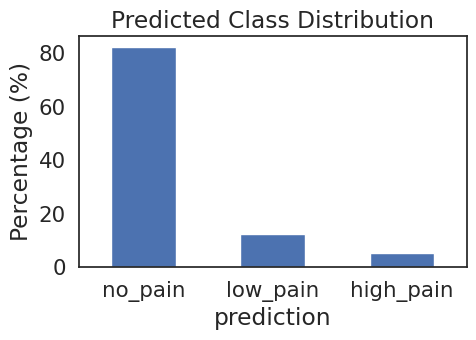

In [ ]:
# K fold submission

print(f"Model input size derived from test sequences: {actual_input_size}")

# rnn_model = RecurrentClassifier(
#     input_size=actual_input_size,
#     hidden_size=HIDDEN_SIZE,
#     num_layers=HIDDEN_LAYERS,
#     num_classes=num_classes,
#     dropout_rate=DROPOUT_RATE,
#     bidirectional=BIDIRECTIONAL,
#     rnn_type=RNN_TYPE
#     ).to(device)

print(f"Model created with input_size={actual_input_size}, hidden_size={HIDDEN_SIZE}")
# It's good practice to summarize the model with the actual input shape it will receive
recurrent_summary(model, input_size=X_test_sequences.shape[1:])

# Load the trained model
#model_path = MODEL_LOAD_PATH
model_path = "/gdrive/My\\ Drive/[2025 - 2026]\\ AN2DL/Challenge 1/Personal Challenge 1/models/fold_2_model.pt"


try:
    # Load the state dict
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint)
    print(f"✓ Model successfully loaded from {model_path}")

    # Verify model architecture matches
    total_params = sum(p.numel() for p in model.parameters())
    print(f"✓ Model loaded with {total_params:,} parameters")

except FileNotFoundError:
    print(f"✗ ERROR: Model file not found at {model_path}")
    print("Please ensure the model was trained and saved properly.")
    print("You may need to retrain the model or check the file path.")
    # Exit or handle the error appropriately if the model cannot be loaded

except RuntimeError as e:
    print(f"✗ ERROR: Model architecture mismatch!")
    print(f"Error details: {str(e)}")
    print("\nThis usually happens when the saved model has a different architecture")
    print("than the current model definition (input_size, hidden_size, num_layers, bidirectional).")
    print("Please ensure the current model definition matches the saved model.")
    # Re-raise the exception after providing diagnostic information
    raise e


model.eval()  # Set model to evaluation mode

print("Starting inference on actual test set...")

# --- Inference Pipeline ---
final_test_preds = []
final_test_probabilities = []
sample_indices = []

print(f"Running inference on {len(test_loader_final)} batches...")

with torch.no_grad():  # Disable gradient computation for inference
    for batch_idx, inputs in enumerate(test_loader_final):
        # DataLoaders for prediction might return a tuple even with one tensor
        xb = inputs[0].to(device)

        # Verify batch dimensions
        if batch_idx == 0:
            print(f"Batch input shape: {xb.shape}")
            print(f"Expected: (batch_size, {WINDOW_SIZE}, {actual_input_size})")

        # Get model predictions
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Get probabilities for confidence analysis
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()

        # Store batch results
        final_test_preds.append(preds)
        final_test_probabilities.append(probabilities)

        # Since test_loader_final is built from sequences, we need to map predictions back to original sample indices
        # The indices for this batch correspond to the sequences generated.
        # We'll need to figure out the mapping from sequence index to original sample_index later for the submission file.
        # For now, just store the predictions.

        # Progress indicator
        if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == len(test_loader_final):
            print(f"Processed batch {batch_idx + 1}/{len(test_loader_final)}")


# Combine all batches into single arrays
final_test_preds = np.concatenate(final_test_preds)
final_test_probabilities = np.concatenate(final_test_probabilities)

print(f"\nInference on actual test set completed successfully!")
print(f"Total predictions: {len(final_test_preds)}")
print(f"Predictions shape: {final_test_preds.shape}")
print(f"Probabilities shape: {final_test_probabilities.shape}")


# --- Create Submission File ---
# Map numerical predictions back to original labels
label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
pred_labels = [label_map[p] for p in final_test_preds]

# The sample_index for the submission file should correspond to the original sample_index from X_test_final_df
# Since build_sequences creates multiple sequences per sample_index (if stride < window),
# we need to associate each prediction with its original sample_index.
# A simple way is to assume each sequence corresponds to the sample_index it came from.
# This might not be perfectly accurate if predictions should be per-sample instead of per-sequence.
# For this submission, we'll create a submission row for each sequence prediction.

# Generate sample indices for the sequences
# The number of sequences is len(final_test_preds)
# We need to replicate the original sample_indices based on how many sequences were generated per sample.
# This requires re-running or adapting the logic from build_sequences to track original indices.

# A simpler approach for submission, if predictions are expected per original sample_index,
# is to average predictions per sample_index or take the majority vote.
# However, the competition usually expects one prediction per sequence/window if the model outputs per sequence.
# Let's assume the submission requires one prediction per sequence generated.

final_results = [] # Initialize final_results list

for sample_id in X_test_final_df['sample_index'].unique():

    # extract rows for this sample
    temp = X_test_final_df[X_test_final_df['sample_index'] == sample_id]

    # If the sample has fewer rows than WINDOW_SIZE, pad it with zeros
    if len(temp) < WINDOW_SIZE:
        padding = pd.DataFrame(0, index=np.arange(WINDOW_SIZE - len(temp)), columns=temp.columns)
        temp = pd.concat([temp, padding], ignore_index=True)

    # build sequences for this sample
    seqs = build_sequences_test(temp, window=WINDOW_SIZE, stride=STRIDE)  # shape: [num_windows, window, features]

    # sometimes build_sequences_test might still return zero sequences if len(temp) < stride
    if len(seqs) == 0:
        # fallback: take the last WINDOW_SIZE rows
        seqs = temp.iloc[-WINDOW_SIZE:].values[np.newaxis, :, :]

    seqs = torch.tensor(seqs, dtype=torch.float32).to(device)

    with torch.no_grad():
        logits = model(seqs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    # Final decision for this sample_index
    final_class = np.bincount(preds).argmax()  # majority vote
    final_results.append({
        "sample_index": sample_id,
        "prediction": label_map[final_class]
    })

submission = pd.DataFrame(final_results)
submission.to_csv(SUBMISSION_FILENAME, index=False)

print(submission.head())
print(f"✅ Saved submission with {len(submission)} rows should be 1324")

# --- Analyze class distribution in final predictions ---
label_counts = submission['prediction'].value_counts(normalize=True) * 100

print("\n📊 Distribution of predicted classes:")
for label in ['no_pain', 'low_pain', 'high_pain']:
    pct = label_counts.get(label, 0.0)
    print(f"   {label:10s}: {pct:6.2f}%")

# Optional: quick sanity check for imbalance
majority_label = label_counts.idxmax()
print(f"\n🧭 Most common predicted label: {majority_label} ({label_counts.max():.2f}%) \n")

# Optional: visualize as a bar chart
import matplotlib.pyplot as plt
desired_order = ["no_pain", "low_pain", "high_pain"]
label_counts_ordered = label_counts.reindex(desired_order)
plt.figure(figsize=(5,3))
(label_counts_ordered
 .plot(kind='bar', rot=0, title='Predicted Class Distribution', ylabel='Percentage (%)'))
plt.show()